# Task 1

Implementing the three-compartment model to compute the forward solution for G(t), B(t), and U(t)

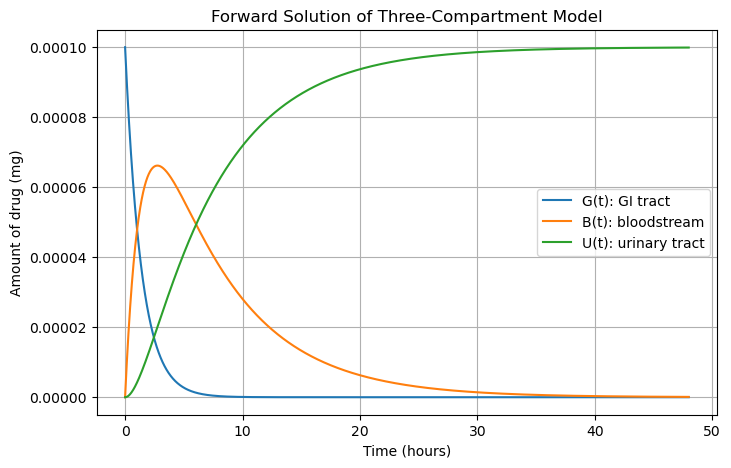

In [44]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from scipy.integrate import solve_ivp

# parameters
kg = 0.72
kb = 0.15
G0 = 1e-4

# define the system of ODEs
def odes(t, y):
    G, B, U = y

    dGdt = -kg * G
    dBdt = kg * G - kb * B
    dUdt = kb * B

    return [dGdt, dBdt, dUdt]


# Time interval for the simulation
T_final = 48.0  # hours

# Time points where the solution is computed
t_eval = np.linspace(0.0, T_final, 2000)

# Initial conditions
G_init = G0
B_init = 0
U_init = 0
y0 = [G_init, B_init, U_init]

# Solve the system of ODEs using RK45
solution = solve_ivp(odes, (0, T_final), y0, t_eval=t_eval, rtol=1e-12, atol=1e-14)

# Extract the results
t = solution.t
G = solution.y[0]
B = solution.y[1]
U = solution.y[2]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(t, G, label="G(t): GI tract")
plt.plot(t, B, label="B(t): bloodstream")
plt.plot(t, U, label="U(t): urinary tract")
plt.xlabel("Time (hours)")
plt.ylabel("Amount of drug (mg)")
plt.title("Forward Solution of Three-Compartment Model")
plt.legend()
plt.grid(True)
plt.show()

# Task 2

Implementing the three-compartment model to compute the forward solution for G(t), B(t), and U(t) using physics-informed neural networks (PINNs) following the methodology in [1].

Outputting hardcoded values of G(t), B(t), and U(t) at T = 24 hours for computing auxiliary loss.

In [45]:
# value of G, B, U at T = 24 hours
T_aux = 24.0
G_aux = np.interp(T_aux, t, G)
B_aux = np.interp(T_aux, t, B)
U_aux = np.interp(T_aux, t, U)

# normalized auxiliary target at T = 24
g_aux = G_aux / G0
b_aux = B_aux / G0
u_aux = U_aux / G0

In [46]:
import time

torch.manual_seed(0)
np.random.seed(0)

# Numerical ground truth from Task 1

t_true_np, y_true_np = t.reshape(-1, 1), np.vstack([G, B, U]).T

# Auxiliary data for computing auxiliary loss

t_aux = torch.tensor([[0.0], [T_aux]], dtype=torch.float32)

y_aux_norm = torch.tensor([
    [1.0, 0.0, 0.0],
    [g_aux, b_aux, u_aux]
], dtype=torch.float32)

# normalized ground truth while choosing 1e-4 as our normalization constant: 
# g = G/G0, b = B/G0, u = U/G0
y_true_norm_np = y_true_np / G0

# Input-scaling layer and feature layer

class FeatureLayer(nn.Module):
    """
    Implements:
        t -> t_tilde = t / T
        features = [t_tilde, exp(-kg*T*t_tilde), exp(-kb*T*t_tilde)]

    Following the methodology in [1], I apply input scaling first, feature construction second.
    """
    def __init__(self, kg=0.72, kb=0.15, T=48.0):
        super().__init__()
        self.kg = kg
        self.kb = kb
        self.T = T

    def forward(self, t):
        t_tilde = t / self.T

        e1 = t_tilde
        e2 = torch.exp(-self.kg * self.T * t_tilde)
        e3 = torch.exp(-self.kb * self.T * t_tilde)

        features = torch.cat([e1, e2, e3], dim=1)
        return features


# Output-scaling layer

class OutputScalingLayer(nn.Module):
    """
    Converts normalized outputs [g, b, u] to physical outputs [G, B, U].

        G_hat = G0 * g_hat
        B_hat = G0 * b_hat
        U_hat = G0 * u_hat
    
    Following the methodology in [1], I apply output scaling at the end such that the values are of order 1.

    I choose G0 as the normalization constant since it is the largest scale in the problem, and this ensures that
    the normalized variables g, b, u are all of order 1.
    """
    def __init__(self, G0=1e-4):
        super().__init__()
        scale = torch.tensor([[G0, G0, G0]], dtype=torch.float32)
        self.register_buffer("scale", scale)

    def forward(self, y_norm):
        return self.scale * y_norm


# PINN model

class PharmacokineticPINN(nn.Module):
    def __init__(self, kg=0.72, kb=0.15, G0=1e-4, T=48.0,
                 hidden_dim=64, num_hidden_layers=3):
        super().__init__()

        self.feature_layer = FeatureLayer(kg=kg, kb=kb, T=T)
        self.output_scaling = OutputScalingLayer(G0=G0)

        layers = []
        input_dim = 3
        output_dim = 3

        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    # We have two forward methods: one that outputs normalized variables (g, b, u) and one that outputs physical variables (G, B, U).
    # The loss is computed in normalized variables, and the final evaluation is done in physical variables.

    # Forward pass in normalized variables
    def forward_normalized(self, t):
        features = self.feature_layer(t)
        y_norm = self.net(features)
        return y_norm

    # Forward pass in physical variables
    def forward(self, t):
        y_norm = self.forward_normalized(t)
        y_physical = self.output_scaling(y_norm)
        return y_physical


# Sampling training data

def sample_training_data(t_true, y_true_norm, N_data):
    """
    Randomly samples N_data points from the numerical ground truth.
    These are the scattered observations used in the PINN data loss.
    """
    indices = np.random.choice(len(t_true), size=N_data, replace=False)

    t_data = t_true[indices]
    y_data_norm = y_true_norm[indices]

    t_data = torch.tensor(t_data, dtype=torch.float32)
    y_data_norm = torch.tensor(y_data_norm, dtype=torch.float32)

    return t_data, y_data_norm


def sample_collocation_points(N_collocation):
    """
    Samples time points where the ODE residual is enforced.
    """
    t_col = torch.rand(N_collocation, 1) * T_final
    t_col.requires_grad_(True)
    return t_col

# PINN Loss function

# Setting default lambda for aux as 10.0 since it is only evaluated at 2 points and I want it to have a significant
# influence on the training.

def pinn_loss(model, t_data, y_data_norm, t_col, t_aux, y_aux_norm,
              lambda_data=1.0,
              lambda_ode=1.0,
              lambda_aux=10.0):
    """
    Loss = data loss + ODE residual loss + auxiliary loss.

    Compute the loss in normalized variables:
        g = G/G0, b = B/G0, u = U/G0
    """

    # Data loss
    y_pred_data_norm = model.forward_normalized(t_data)

    loss_data = torch.mean((y_pred_data_norm - y_data_norm) ** 2)

    # ODE residual loss
    y_col_norm = model.forward_normalized(t_col)

    g = y_col_norm[:, 0:1]
    b = y_col_norm[:, 1:2]
    u = y_col_norm[:, 2:3]

    dgdt = torch.autograd.grad(
        g, t_col,
        grad_outputs=torch.ones_like(g),
        create_graph=True
    )[0]

    dbdt = torch.autograd.grad(
        b, t_col,
        grad_outputs=torch.ones_like(b),
        create_graph=True
    )[0]

    dudt = torch.autograd.grad(
        u, t_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    r_g = dgdt + kg * g
    r_b = dbdt - kg * g + kb * b
    r_u = dudt - kb * b

    loss_ode = torch.mean(r_g ** 2) + torch.mean(r_b ** 2) + torch.mean(r_u ** 2)

    # Auxiliary loss
    y_aux_pred_norm = model.forward_normalized(t_aux)

    loss_aux = 0.5 * (
        torch.sum((y_aux_pred_norm[0:1] - y_aux_norm[0:1]) ** 2)
        + torch.sum((y_aux_pred_norm[1:2] - y_aux_norm[1:2]) ** 2)
    )

    # Total loss
    total_loss = (
        lambda_data * loss_data
        + lambda_ode * loss_ode
        + lambda_aux * loss_aux
    )

    return total_loss, loss_data, loss_ode, loss_aux


# Training function

def train_pinn(
    N_data=100,
    N_collocation=1000,
    epochs=10000,
    learning_rate=1e-3,
    print_every=1000
):
    model = PharmacokineticPINN(
        kg=kg,
        kb=kb,
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, y_data_norm = sample_training_data(
        t_true_np,
        y_true_norm_np,
        N_data=N_data
    )

    start_time = time.time()

    history = {
        "total": [],
        "data": [],
        "ode": [],
        "aux": []
    }

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss, loss_data, loss_ode, loss_aux = pinn_loss(
            model,
            t_data,
            y_data_norm,
            t_col,
            t_aux,
            y_aux_norm,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_aux=10.0
        )

        loss.backward()
        optimizer.step()

        history["total"].append(loss.item())
        history["data"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.3e} | "
                f"Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Auxiliary: {loss_aux.item():.3e}"
            )

    training_time = time.time() - start_time

    return model, history, training_time

In [47]:
# Train the PINN

model, history, training_time = train_pinn(
    N_data=100,
    N_collocation=1000,
    epochs=10000,
    learning_rate=1e-3,
    print_every=1000
)

print(f"\nTraining time: {training_time:.2f} seconds")

Epoch  1000 | Total: 7.849e-03 | Data: 4.422e-03 | ODE: 3.211e-03 | Auxiliary: 2.160e-05
Epoch  2000 | Total: 2.199e-04 | Data: 1.259e-04 | ODE: 8.904e-05 | Auxiliary: 4.998e-07
Epoch  3000 | Total: 6.934e-05 | Data: 1.415e-05 | ODE: 5.479e-05 | Auxiliary: 4.060e-08
Epoch  4000 | Total: 6.755e-05 | Data: 1.016e-05 | ODE: 5.720e-05 | Auxiliary: 1.854e-08
Epoch  5000 | Total: 3.548e-05 | Data: 6.798e-06 | ODE: 2.853e-05 | Auxiliary: 1.501e-08
Epoch  6000 | Total: 2.228e-05 | Data: 4.547e-06 | ODE: 1.334e-05 | Auxiliary: 4.401e-07
Epoch  7000 | Total: 1.542e-05 | Data: 3.350e-06 | ODE: 1.197e-05 | Auxiliary: 1.054e-08
Epoch  8000 | Total: 1.100e-05 | Data: 2.600e-06 | ODE: 7.791e-06 | Auxiliary: 6.120e-08
Epoch  9000 | Total: 7.767e-05 | Data: 4.006e-06 | ODE: 7.207e-06 | Auxiliary: 6.646e-06
Epoch 10000 | Total: 2.348e-05 | Data: 2.301e-06 | ODE: 6.007e-06 | Auxiliary: 1.517e-06

Training time: 15.82 seconds


Test MSE, physical units:   1.494e-14
Test MSE, normalized units: 1.494e-06


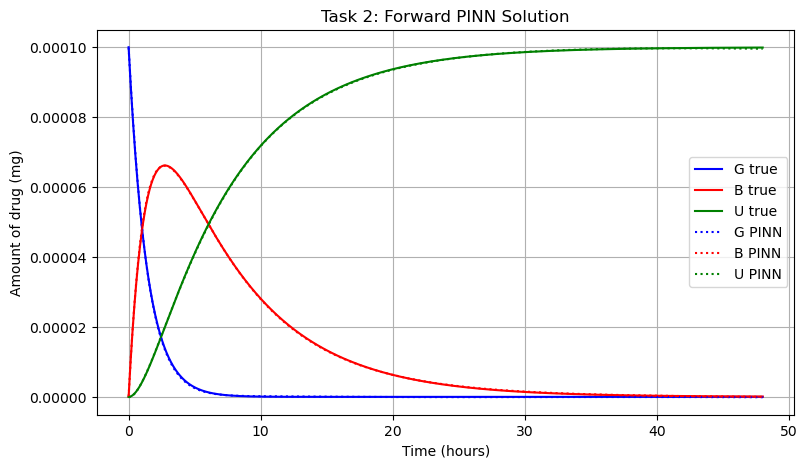

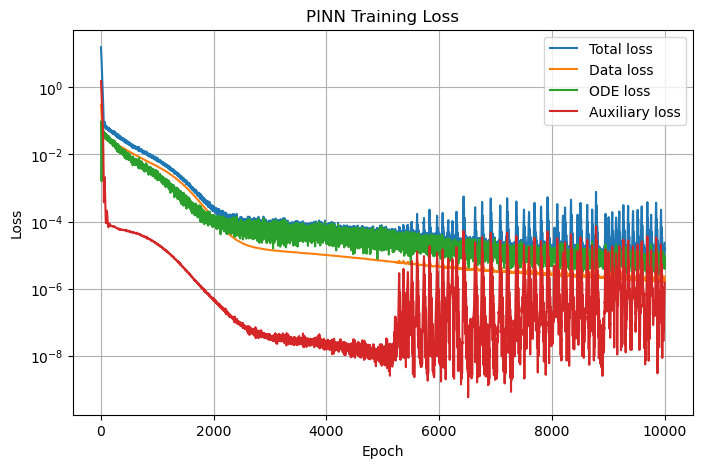

In [48]:
# Evaluate and plot results

model.eval()

t_test = torch.tensor(t_true_np, dtype=torch.float32)

with torch.no_grad():
    y_pred_physical = model(t_test).cpu().numpy()
    y_pred_norm = y_pred_physical / G0

G_pred = y_pred_physical[:, 0]
B_pred = y_pred_physical[:, 1]
U_pred = y_pred_physical[:, 2]

G_true = y_true_np[:, 0]
B_true = y_true_np[:, 1]
U_true = y_true_np[:, 2]

test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)
test_mse_normalized = np.mean((y_pred_norm - y_true_norm_np) ** 2)

print(f"Test MSE, physical units:   {test_mse_physical:.3e}")
print(f"Test MSE, normalized units: {test_mse_normalized:.3e}")


plt.figure(figsize=(9, 5))

plt.plot(t_true_np, G_true, "b-", label="G true")
plt.plot(t_true_np, B_true, "r-", label="B true")
plt.plot(t_true_np, U_true, "g-", label="U true")

plt.plot(t_true_np, G_pred, "b:", label="G PINN")
plt.plot(t_true_np, B_pred, "r:", label="B PINN")
plt.plot(t_true_np, U_pred, "g:", label="U PINN")

plt.xlabel("Time (hours)")
plt.ylabel("Amount of drug (mg)")
plt.title("Task 2: Forward PINN Solution")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss history

plt.figure(figsize=(8, 5))
plt.semilogy(history["total"], label="Total loss")
plt.semilogy(history["data"], label="Data loss")
plt.semilogy(history["ode"], label="ODE loss")
plt.semilogy(history["aux"], label="Auxiliary loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Task 3

Performing PINN forward solution and comparing with ground truth using different sample sizes. Plotting MSE vs. sample size and reporting computational time.

In [49]:
# Helper to evaluate the model on the dense grid and compute MSEs
def evaluate_model(model, t_true_np, y_true_np, y_true_norm_np):
    model.eval()

    t_test = torch.tensor(t_true_np, dtype=torch.float32)

    with torch.no_grad():
        y_pred_physical = model(t_test).cpu().numpy()

    y_pred_norm = y_pred_physical / G0

    test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)
    test_mse_normalized = np.mean((y_pred_norm - y_true_norm_np) ** 2)

    relative_l2_error = (
        np.linalg.norm(y_pred_physical - y_true_np)
        / np.linalg.norm(y_true_np)
    )

    return test_mse_physical, test_mse_normalized, relative_l2_error, y_pred_physical

# Sample sizes to investigate
sample_sizes = list(range(10, 401, 10))

task3_results = []

N_collocation = 1000
epochs = 10000
learning_rate = 1e-3

for N_data in sample_sizes:
    print(f"\n======================================")
    print(f"Training PINN with Sample Size = {N_data}")
    print(f"======================================")

    torch.manual_seed(0)
    np.random.seed(0)

    model_N, history_N, training_time_N = train_pinn(
        N_data=N_data,
        N_collocation=N_collocation,
        epochs=epochs,
        learning_rate=learning_rate,
        print_every=epochs
    )

    test_mse_physical_N, test_mse_normalized_N, relative_l2_error, y_pred_physical_N = evaluate_model(
        model_N,
        t_true_np,
        y_true_np,
        y_true_norm_np
    )

    task3_results.append({
        "N_data": N_data,
        "test_mse_physical": test_mse_physical_N,
        "test_mse_normalized": test_mse_normalized_N,
        "relative_l2_error": relative_l2_error,
        "training_time": training_time_N,
        "model": model_N,
        "history": history_N,
        "y_pred_physical": y_pred_physical_N
    })

    print(f"Sample Size = {N_data}")
    print(f"Test MSE, physical units: {test_mse_physical_N:.3e}")
    print(f"Test MSE, normalized units: {test_mse_normalized_N:.3e}")
    print(f"Training time: {training_time_N:.2f} seconds")

N_values = np.array([r["N_data"] for r in task3_results])
mse_physical_values = np.array([r["test_mse_physical"] for r in task3_results])
mse_normalized_values = np.array([r["test_mse_normalized"] for r in task3_results])
relative_l2_errors = np.array([r["relative_l2_error"] for r in task3_results])
training_times = np.array([r["training_time"] for r in task3_results])


Training PINN with Sample Size = 10
Epoch 10000 | Total: 8.298e-06 | Data: 1.959e-06 | ODE: 5.536e-06 | Auxiliary: 8.032e-08
Sample Size = 10
Test MSE, physical units: 2.312e-14
Test MSE, normalized units: 2.312e-06
Training time: 14.24 seconds

Training PINN with Sample Size = 20
Epoch 10000 | Total: 2.476e-04 | Data: 7.509e-06 | ODE: 2.345e-05 | Auxiliary: 2.166e-05
Sample Size = 20
Test MSE, physical units: 5.924e-14
Test MSE, normalized units: 5.924e-06
Training time: 14.13 seconds

Training PINN with Sample Size = 30
Epoch 10000 | Total: 2.162e-04 | Data: 4.414e-06 | ODE: 1.435e-05 | Auxiliary: 1.975e-05
Sample Size = 30
Test MSE, physical units: 7.464e-14
Test MSE, normalized units: 7.464e-06
Training time: 13.76 seconds

Training PINN with Sample Size = 40
Epoch 10000 | Total: 2.913e-05 | Data: 1.388e-06 | ODE: 5.568e-06 | Auxiliary: 2.218e-06
Sample Size = 40
Test MSE, physical units: 1.869e-14
Test MSE, normalized units: 1.869e-06
Training time: 13.84 seconds

Training PINN w

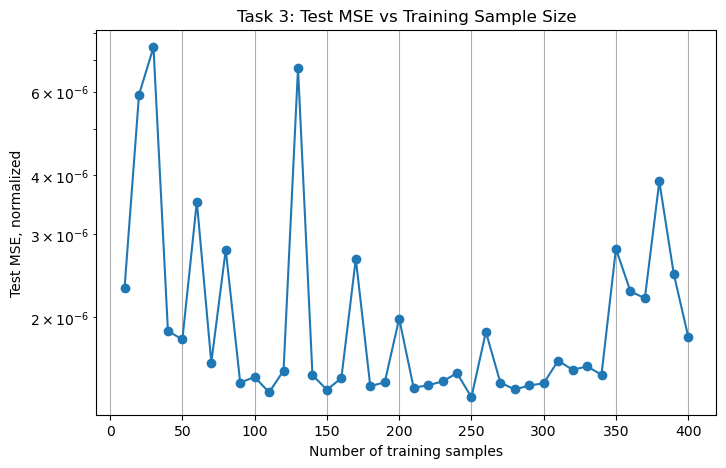

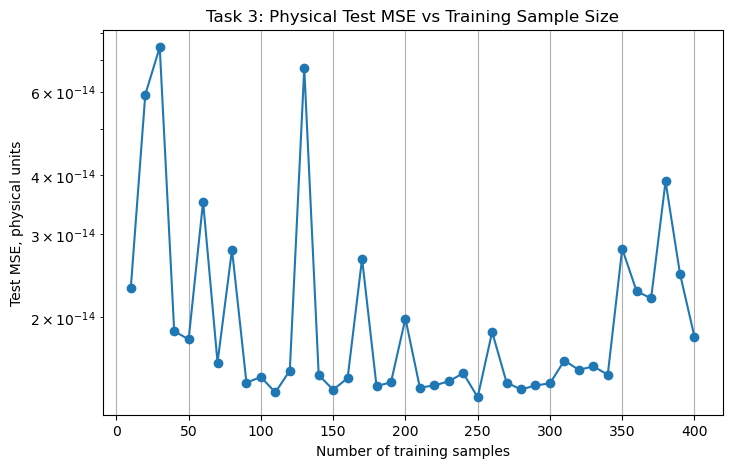

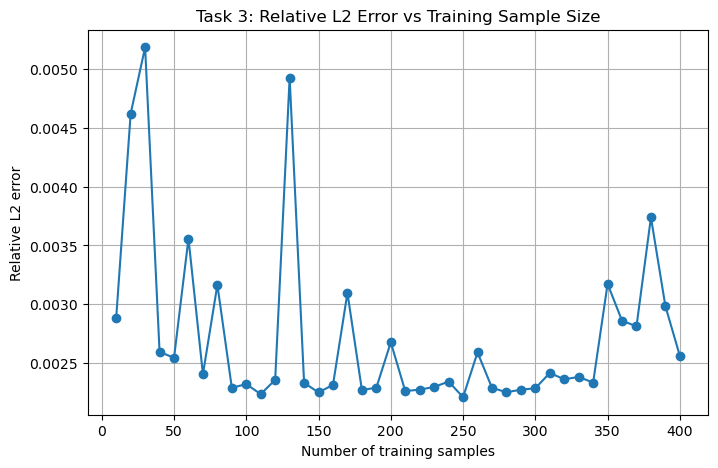

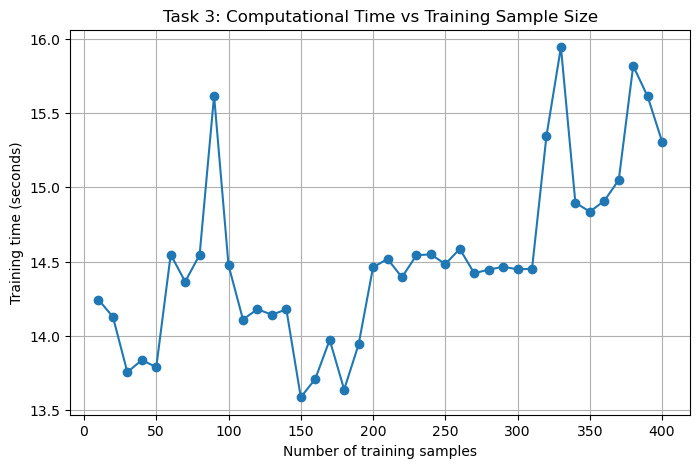

,N_data,test_mse_physical,test_mse_normalized,training_time_seconds
0,10,2.311606e-14,0.000002,14.243947
1,20,5.924334e-14,0.000006,14.127689
2,30,7.463592e-14,0.000007,13.755311
3,40,1.868948e-14,0.000002,13.837044
4,50,1.795118e-14,0.000002,13.789059
5,60,3.514715e-14,0.000004,14.547504
6,70,1.603713e-14,0.000002,14.364625
7,80,2.780668e-14,0.000003,14.545927
8,90,1.453984e-14,0.000001,15.617801
9,100,1.494094e-14,0.000001,14.475344


In [50]:
plt.figure(figsize=(8, 5))
plt.semilogy(N_values, mse_normalized_values, marker="o")
plt.xlabel("Number of training samples")
plt.ylabel("Test MSE, normalized")
plt.title("Task 3: Test MSE vs Training Sample Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(N_values, mse_physical_values, marker="o")
plt.xlabel("Number of training samples")
plt.ylabel("Test MSE, physical units")
plt.title("Task 3: Physical Test MSE vs Training Sample Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(N_values, relative_l2_errors, marker="o")
plt.xlabel("Number of training samples")
plt.ylabel("Relative L2 error")
plt.title("Task 3: Relative L2 Error vs Training Sample Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(N_values, training_times, marker="o")
plt.xlabel("Number of training samples")
plt.ylabel("Training time (seconds)")
plt.title("Task 3: Computational Time vs Training Sample Size")
plt.grid(True)
plt.show()

import pandas as pd

task3_df = pd.DataFrame({
    "N_data": N_values,
    "test_mse_physical": mse_physical_values,
    "test_mse_normalized": mse_normalized_values,
    "training_time_seconds": training_times
})

task3_df

No discernable decrease in Test MSE with increasing sample size, suggesting that the performance bottleneck is not the number of training samples but rather the optimization process and model architecture. As for the computational time, it increases with sample size, but not by much. This indicates that the computational bottleneck is not the training on more samples. It is likely that calculating the ODE loss and optimizing the model parameters takes more time.

# Task 4

Implementing and performing inverse PINN to estimate model parameters (kg and kb) from synthetic data. Repeating experiment for increasing number of samples and reporting recovered parameters, MSE and computational time.

All inverse PINN experiments will be ran with 20000 epochs instead of the previous 10000 epochs.

In [51]:
# Input-scaling layer and feature layer modified for inverse problem

class InverseFeatureLayer(nn.Module):
    """
    Similar to feature layer for the forward solution, but I cannot use kg and kb in the features
    since these are unknown values.

    I am implementing using fixed decay rates of 10 and 30 in the features instead of kg and kb. These are
    just heuristic choices to capture the expected decay behavior without using the true kg and kb values.

    Implements:
        t -> t_tilde = t / T
        features = [t_tilde, exp(-10*t_tilde), exp(-30*t_tilde)]
    """
    def __init__(self, T=48.0):
        super().__init__()
        self.T = T

    def forward(self, t):
        t_tilde = t / self.T

        e1 = t_tilde
        e2 = torch.exp(-10.0 * t_tilde)
        e3 = torch.exp(-30.0 * t_tilde)

        return torch.cat([e1, e2, e3], dim=1)


class InversePharmacokineticPINN(nn.Module):
    def __init__(
        self,
        G0=1e-4,
        T=48.0,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=None,
        kb_init=None
    ):
        super().__init__()

        self.feature_layer = InverseFeatureLayer(T=T)
        self.output_scaling = OutputScalingLayer(G0=G0)

        if kg_init is None:
            kg_init = 0.5
        if kb_init is None:
            kb_init = 0.5

        # Trainable raw parameters initialized as 0.5.
        self.kg_hat = nn.Parameter(torch.tensor([kg_init], dtype=torch.float32))
        self.kb_hat = nn.Parameter(torch.tensor([kb_init], dtype=torch.float32))

        layers = []
        input_dim = 3
        output_dim = 3

        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    # Again, we have two forward methods: one that outputs normalized variables and one that outputs physical variables.
    # The loss is computed in normalized variables, and the final evaluation is done in physical variables.

    def forward_normalized(self, t):
        features = self.feature_layer(t)
        y_norm = self.net(features)
        return y_norm

    def forward(self, t):
        y_norm = self.forward_normalized(t)
        y_physical = self.output_scaling(y_norm)
        return y_physical
    

# Inverse PINN loss function

# Again, weighing lambda_aux more heavily

def inverse_pinn_loss(model, t_data, y_data_norm, t_col, t_aux, y_aux_norm,
                      lambda_data=1.0,
                      lambda_ode=1.0,
                      lambda_aux=10.0):
    """
    Inverse PINN loss.

    The network learns:
        g(t), b(t), u(t), kg, kb

    Loss = data loss + ODE residual loss + auxiliary loss.
    """

    # Data loss
    y_pred_data_norm = model.forward_normalized(t_data)

    loss_data = torch.mean((y_pred_data_norm - y_data_norm) ** 2)

    # ODE residual loss
    y_col_norm = model.forward_normalized(t_col)

    g = y_col_norm[:, 0:1]
    b = y_col_norm[:, 1:2]
    u = y_col_norm[:, 2:3]

    dgdt = torch.autograd.grad(
        g, t_col,
        grad_outputs=torch.ones_like(g),
        create_graph=True
    )[0]

    dbdt = torch.autograd.grad(
        b, t_col,
        grad_outputs=torch.ones_like(b),
        create_graph=True
    )[0]

    dudt = torch.autograd.grad(
        u, t_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    kg_hat = model.kg_hat
    kb_hat = model.kb_hat

    r_g = dgdt + kg_hat * g
    r_b = dbdt - kg_hat * g + kb_hat * b
    r_u = dudt - kb_hat * b

    loss_ode = torch.mean(r_g ** 2) + torch.mean(r_b ** 2) + torch.mean(r_u ** 2)

    # Auxiliary loss
    y_aux_pred_norm = model.forward_normalized(t_aux)

    loss_aux = 0.5 * (
        torch.sum((y_aux_pred_norm[0:1] - y_aux_norm[0:1]) ** 2)
        + torch.sum((y_aux_pred_norm[1:2] - y_aux_norm[1:2]) ** 2)
    )

    # Total loss
    total_loss = (
        lambda_data * loss_data
        + lambda_ode * loss_ode
        + lambda_aux * loss_aux
    )

    return total_loss, loss_data, loss_ode, loss_aux

# Inverse PINN training function

def train_inverse_pinn(
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
):
    model = InversePharmacokineticPINN(
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, y_data_norm = sample_training_data(
        t_true_np,
        y_true_norm_np,
        N_data=N_data
    )

    start_time = time.time()

    history = {
        "total": [],
        "data": [],
        "ode": [],
        "aux": [],
        "kg": [],
        "kb": []
    }

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss, loss_data, loss_ode, loss_aux = inverse_pinn_loss(
            model,
            t_data,
            y_data_norm,
            t_col,
            t_aux,
            y_aux_norm,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_aux=10.0
        )

        loss.backward()
        optimizer.step()

        kg_current = model.kg_hat.item()
        kb_current = model.kb_hat.item()

        history["total"].append(loss.item())
        history["data"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())
        history["kg"].append(kg_current)
        history["kb"].append(kb_current)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.3e} | "
                f"Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Aux: {loss_aux.item():.3e} | "
                f"kg: {kg_current:.5f} | "
                f"kb: {kb_current:.5f}"
            )

    training_time = time.time() - start_time

    return model, history, training_time, t_data, y_data_norm

# Helper to evaluate the inverse PINN model on the dense grid and compute MSEs, as well as extract learned parameters kg and kb.

def evaluate_inverse_model(model, t_true_np, y_true_np, y_true_norm_np):
    model.eval()

    t_test = torch.tensor(t_true_np, dtype=torch.float32)

    with torch.no_grad():
        y_pred_physical = model(t_test).cpu().numpy()

    y_pred_norm = y_pred_physical / G0

    test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)
    test_mse_normalized = np.mean((y_pred_norm - y_true_norm_np) ** 2)

    relative_l2_error = (
        np.linalg.norm(y_pred_physical - y_true_np)
        / np.linalg.norm(y_true_np)
    )

    kg_recovered = model.kg_hat.item()
    kb_recovered = model.kb_hat.item()

    return test_mse_physical, test_mse_normalized, relative_l2_error, kg_recovered, kb_recovered, y_pred_physical

In [52]:
# Running Inverse PINN training and evaluation once

inverse_model, inverse_history, inverse_training_time, t_train_inv, y_train_inv_norm = train_inverse_pinn(
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
)

test_mse_physical, test_mse_normalized, relative_l2_error, kg_recovered, kb_recovered, y_pred_physical = evaluate_inverse_model(
    inverse_model,
    t_true_np,
    y_true_np,
    y_true_norm_np
)

print("\nInverse PINN results")
print(f"Recovered kg: {kg_recovered:.6f} | True kg: {kg:.6f} | Error: {abs(kg_recovered - kg):.3e}")
print(f"Recovered kb: {kb_recovered:.6f} | True kb: {kb:.6f} | Error: {abs(kb_recovered - kb):.3e}")
print(f"Test MSE, physical units: {test_mse_physical:.3e}")
print(f"Test MSE, normalized units: {test_mse_normalized:.3e}")
print(f"Relative L2 error: {relative_l2_error:.3e}")
print(f"Training time: {inverse_training_time:.2f} seconds")

Epoch  1000 | Total: 7.402e-03 | Data: 6.157e-03 | ODE: 1.069e-03 | Aux: 1.762e-05 | kg: 0.32519 | kb: 0.16097
Epoch  2000 | Total: 1.191e-03 | Data: 8.500e-04 | ODE: 3.195e-04 | Aux: 2.133e-06 | kg: 0.50960 | kb: 0.16776
Epoch  3000 | Total: 2.940e-04 | Data: 2.178e-04 | ODE: 7.163e-05 | Aux: 4.609e-07 | kg: 0.62678 | kb: 0.15495
Epoch  4000 | Total: 2.701e-04 | Data: 1.699e-04 | ODE: 7.852e-05 | Aux: 2.175e-06 | kg: 0.64047 | kb: 0.15269
Epoch  5000 | Total: 2.059e-04 | Data: 1.211e-04 | ODE: 6.301e-05 | Aux: 2.185e-06 | kg: 0.64422 | kb: 0.15105
Epoch  6000 | Total: 1.090e-04 | Data: 6.875e-05 | ODE: 3.719e-05 | Aux: 3.089e-07 | kg: 0.65055 | kb: 0.14967
Epoch  7000 | Total: 5.728e-05 | Data: 3.699e-05 | ODE: 1.951e-05 | Aux: 7.770e-08 | kg: 0.66255 | kb: 0.14857
Epoch  8000 | Total: 9.011e-05 | Data: 1.776e-05 | ODE: 1.013e-05 | Aux: 6.223e-06 | kg: 0.67840 | kb: 0.14925
Epoch  9000 | Total: 2.392e-05 | Data: 1.291e-05 | ODE: 5.040e-06 | Aux: 5.975e-07 | kg: 0.69144 | kb: 0.14915
E

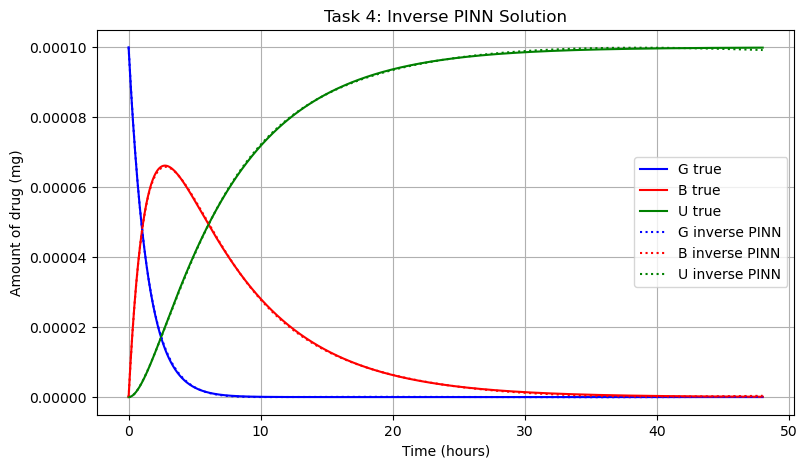

In [53]:
G_pred_inv = y_pred_physical[:, 0]
B_pred_inv = y_pred_physical[:, 1]
U_pred_inv = y_pred_physical[:, 2]

G_true = y_true_np[:, 0]
B_true = y_true_np[:, 1]
U_true = y_true_np[:, 2]

plt.figure(figsize=(9, 5))

plt.plot(t_true_np, G_true, "b-", label="G true")
plt.plot(t_true_np, B_true, "r-", label="B true")
plt.plot(t_true_np, U_true, "g-", label="U true")

plt.plot(t_true_np, G_pred_inv, "b:", label="G inverse PINN")
plt.plot(t_true_np, B_pred_inv, "r:", label="B inverse PINN")
plt.plot(t_true_np, U_pred_inv, "g:", label="U inverse PINN")

plt.xlabel("Time (hours)")
plt.ylabel("Amount of drug (mg)")
plt.title("Task 4: Inverse PINN Solution")
plt.legend()
plt.grid(True)
plt.show()

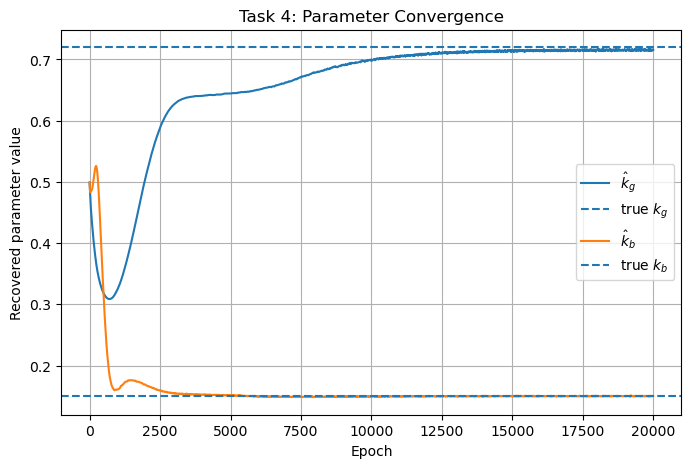

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(inverse_history["kg"], label=r"$\hat{k}_g$")
plt.axhline(kg, linestyle="--", label=r"true $k_g$")
plt.plot(inverse_history["kb"], label=r"$\hat{k}_b$")
plt.axhline(kb, linestyle="--", label=r"true $k_b$")
plt.xlabel("Epoch")
plt.ylabel("Recovered parameter value")
plt.title("Task 4: Parameter Convergence")
plt.legend()
plt.grid(True)
plt.show()

Repeating inverse PINN experiment for increasing number of samples and reporting recovered parameters, MSE and computational time.

In [55]:
# Sample sizes to investigate for inverse PINN

sample_sizes = list(range(10, 401, 10))

task4_results = []

N_collocation = 1000
epochs = 20000
learning_rate = 1e-3

for N_data in sample_sizes:
    print(f"\n======================================")
    print(f"Inverse PINN with N_data = {N_data}")
    print(f"======================================")

    torch.manual_seed(0)
    np.random.seed(0)

    model_N, history_N, training_time_N, _, _ = train_inverse_pinn(
        N_data=N_data,
        N_collocation=N_collocation,
        epochs=epochs,
        learning_rate=learning_rate,
        print_every=epochs,
    )

    mse_physical_N, mse_normalized_N, relative_l2_error, kg_rec_N, kb_rec_N, y_pred_N = evaluate_inverse_model(
        model_N,
        t_true_np,
        y_true_np,
        y_true_norm_np
    )

    task4_results.append({
        "N_data": N_data,
        "kg_recovered": kg_rec_N,
        "kb_recovered": kb_rec_N,
        "kg_error": abs(kg_rec_N - kg),
        "kb_error": abs(kb_rec_N - kb),
        "test_mse_physical": mse_physical_N,
        "test_mse_normalized": mse_normalized_N,
        "relative_l2_error": relative_l2_error,
        "training_time": training_time_N
    })

    print(f"N_data: {N_data}")
    print(f"Recovered kg: {kg_rec_N:.6f} | Error: {abs(kg_rec_N - kg):.3e}")
    print(f"Recovered kb: {kb_rec_N:.6f} | Error: {abs(kb_rec_N - kb):.3e}")
    print(f"Physical MSE: {mse_physical_N:.3e}")
    print(f"Relative L2 error: {relative_l2_error:.3e}")
    print(f"Training time: {training_time_N:.2f} seconds")

task4_df = pd.DataFrame(task4_results)

task4_df


Inverse PINN with N_data = 10
Epoch 20000 | Total: 2.803e-05 | Data: 2.506e-06 | ODE: 3.074e-06 | Aux: 2.245e-06 | kg: 0.71447 | kb: 0.14932
N_data: 10
Recovered kg: 0.714471 | Error: 5.529e-03
Recovered kb: 0.149318 | Error: 6.822e-04
Physical MSE: 6.639e-14
Relative L2 error: 4.891e-03
Training time: 30.75 seconds

Inverse PINN with N_data = 20
Epoch 20000 | Total: 1.449e-05 | Data: 6.107e-06 | ODE: 3.046e-06 | Aux: 5.339e-07 | kg: 0.70800 | kb: 0.15044
N_data: 20
Recovered kg: 0.708002 | Error: 1.200e-02
Recovered kb: 0.150444 | Error: 4.441e-04
Physical MSE: 4.388e-14
Relative L2 error: 3.977e-03
Training time: 29.78 seconds

Inverse PINN with N_data = 30
Epoch 20000 | Total: 1.009e-05 | Data: 6.118e-06 | ODE: 3.239e-06 | Aux: 7.347e-08 | kg: 0.69814 | kb: 0.15021
N_data: 30
Recovered kg: 0.698138 | Error: 2.186e-02
Recovered kb: 0.150212 | Error: 2.117e-04
Physical MSE: 6.971e-14
Relative L2 error: 5.012e-03
Training time: 28.54 seconds

Inverse PINN with N_data = 40
Epoch 20000 

,N_data,kg_recovered,kb_recovered,kg_error,kb_error,test_mse_physical,test_mse_normalized,relative_l2_error,training_time
0,10,0.714471,0.149318,0.005529,0.000682,6.639262e-14,0.000007,0.004891,30.747770
1,20,0.708002,0.150444,0.011998,0.000444,4.388473e-14,0.000004,0.003977,29.780581
2,30,0.698138,0.150212,0.021862,0.000212,6.971228e-14,0.000007,0.005012,28.537375
3,40,0.694126,0.149870,0.025874,0.000130,1.183800e-13,0.000012,0.006531,28.240808
4,50,0.712143,0.150045,0.007857,0.000045,3.854937e-14,0.000004,0.003727,30.251502
5,60,0.713365,0.150007,0.006635,0.000007,5.167363e-14,0.000005,0.004315,29.622535
6,70,0.713916,0.149916,0.006084,0.000084,3.927952e-14,0.000004,0.003762,29.967668
7,80,0.714155,0.149773,0.005845,0.000227,6.379666e-14,0.000006,0.004795,30.224066
8,90,0.713950,0.149752,0.006050,0.000248,1.194292e-13,0.000012,0.006560,29.830646
9,100,0.714772,0.149811,0.005228,0.000189,3.934582e-14,0.000004,0.003765,30.002818


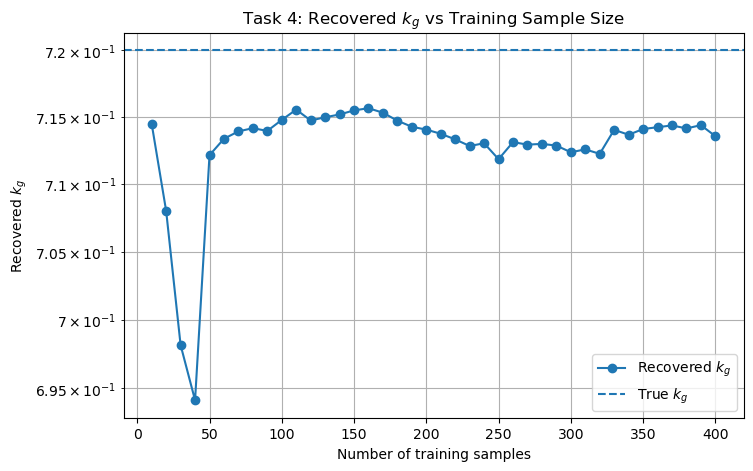

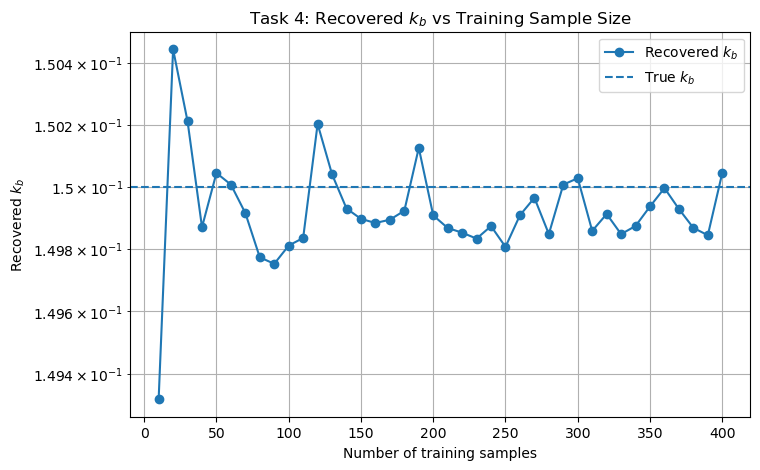

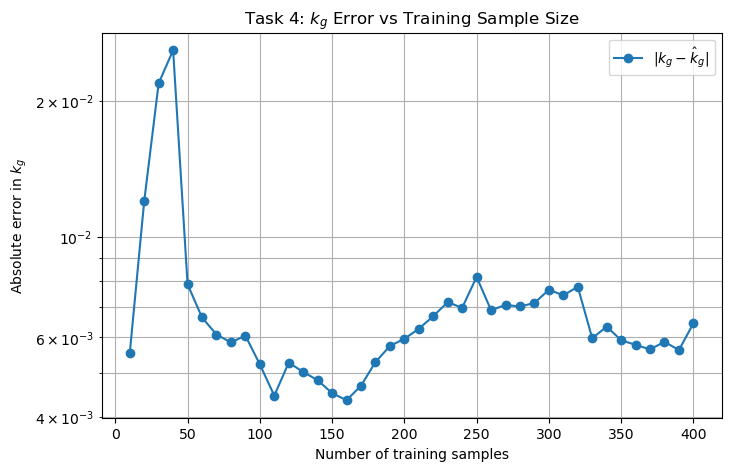

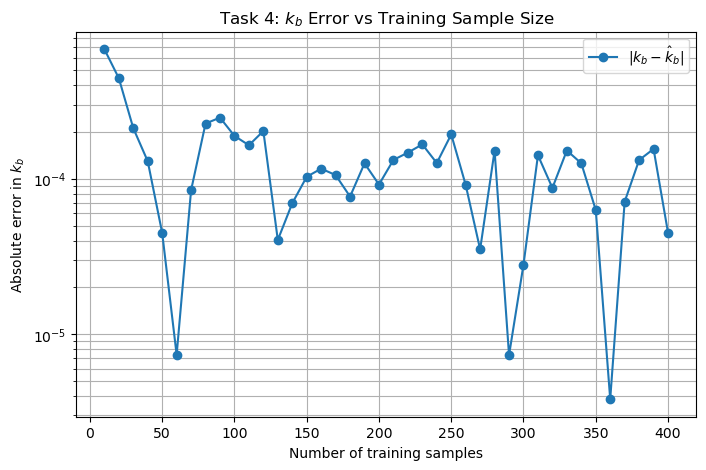

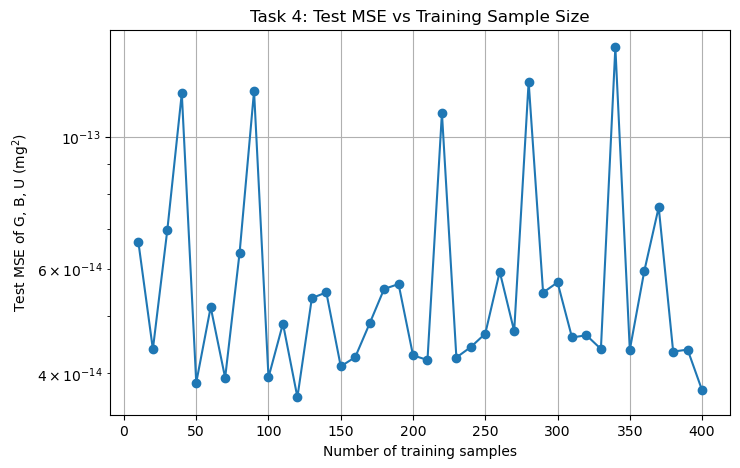

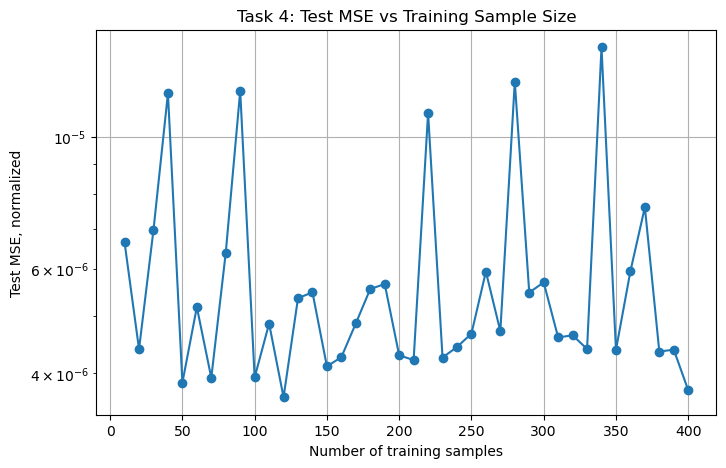

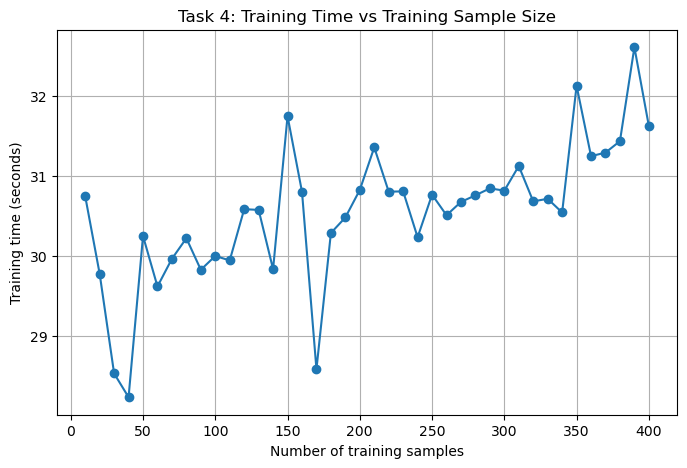

In [56]:
# Plot recovered kg vs training sample size
plt.figure(figsize=(8, 5))

plt.semilogy(
    task4_df["N_data"],
    task4_df["kg_recovered"],
    marker="o",
    label=r"Recovered $k_g$"
)

plt.axhline(
    kg,
    linestyle="--",
    label=r"True $k_g$"
)

plt.xlabel("Number of training samples")
plt.ylabel(r"Recovered $k_g$")
plt.title(r"Task 4: Recovered $k_g$ vs Training Sample Size")
plt.legend()
plt.grid(True, which="both")
plt.show()

# Plot recovered kb vs training sample size
plt.figure(figsize=(8, 5))

plt.semilogy(
    task4_df["N_data"],
    task4_df["kb_recovered"],
    marker="o",
    label=r"Recovered $k_b$"
)

plt.axhline(
    kb,
    linestyle="--",
    label=r"True $k_b$"
)

plt.xlabel("Number of training samples")
plt.ylabel(r"Recovered $k_b$")
plt.title(r"Task 4: Recovered $k_b$ vs Training Sample Size")
plt.legend()
plt.grid(True, which="both")
plt.show()

# Plot kg absolute error
plt.figure(figsize=(8, 5))

plt.semilogy(
    task4_df["N_data"],
    task4_df["kg_error"],
    marker="o",
    label=r"$|k_g - \hat{k}_g|$"
)

plt.xlabel("Number of training samples")
plt.ylabel(r"Absolute error in $k_g$")
plt.title(r"Task 4: $k_g$ Error vs Training Sample Size")
plt.legend()
plt.grid(True, which="both")
plt.show()

# Plot kb absolute error
plt.figure(figsize=(8, 5))

plt.semilogy(
    task4_df["N_data"],
    task4_df["kb_error"],
    marker="o",
    label=r"$|k_b - \hat{k}_b|$"
)

plt.xlabel("Number of training samples")
plt.ylabel(r"Absolute error in $k_b$")
plt.title(r"Task 4: $k_b$ Error vs Training Sample Size")
plt.legend()
plt.grid(True, which="both")
plt.show()

# Plotting test MSE in physical units vs training sample size
plt.figure(figsize=(8, 5))

plt.semilogy(task4_df["N_data"], task4_df["test_mse_physical"], marker="o")

plt.xlabel("Number of training samples")
plt.ylabel("Test MSE of G, B, U (mg$^2$)")
plt.title("Task 4: Test MSE vs Training Sample Size")
plt.grid(True)
plt.show()

# Plotting test MSE in normalized units vs training sample size
plt.figure(figsize=(8, 5))

plt.semilogy(task4_df["N_data"], task4_df["test_mse_normalized"], marker="o")

plt.xlabel("Number of training samples")
plt.ylabel("Test MSE, normalized")
plt.title("Task 4: Test MSE vs Training Sample Size")
plt.grid(True)
plt.show()

# Plotting training time vs training sample size
plt.figure(figsize=(8, 5))

plt.plot(task4_df["N_data"], task4_df["training_time"], marker="o")

plt.xlabel("Number of training samples")
plt.ylabel("Training time (seconds)")
plt.title("Task 4: Training Time vs Training Sample Size")
plt.grid(True)
plt.show()

# Task 5

In a situation where only partial observations (e.g. B(t) only) are available, kg and kb should still be recoverable using an inverse PINN. This is because, once we are given an initial condition, with the true trajectory of even one of the compartments, we should be able to recover the parameters by enforcing the physics of the system. Instead of using the MSE of all three compartments in the loss function, we can just use the MSE of the observed compartment (e.g. B(t)) and still recover kg and kb. It is possible that we might need to use more collocation points or train for more epochs to get good parameter recovery, but in principle, it should be possible.

Testing the above hypothesis by performing inverse PINN with only B(t) observations.

In [57]:
def sample_training_data_B_only(t_true, y_true_norm, N_data):
    """
    Randomly samples N_data points, but only returns B(t) observations.

    y_true_norm columns:
        0 = g = G/G0
        1 = b = B/G0
        2 = u = U/G0
    """
    indices = np.random.choice(len(t_true), size=N_data, replace=False)

    t_data = t_true[indices]
    b_data_norm = y_true_norm[indices, 1:2]

    t_data = torch.tensor(t_data, dtype=torch.float32)
    b_data_norm = torch.tensor(b_data_norm, dtype=torch.float32)

    return t_data, b_data_norm

def inverse_pinn_loss_B_only(
    model,
    t_data,
    b_data_norm,
    t_col,
    t_aux_B,
    b_aux_norm,
    lambda_data=1.0,
    lambda_ode=1.0,
    lambda_aux=10.0
):
    """
    B-only inverse PINN loss.

    Observed:
        B(t) samples only

    Auxiliary:
        full initial condition at t=0
        B(T_aux) only at T_aux = 24
    """

    # Data loss
    y_pred_data_norm = model.forward_normalized(t_data)
    b_pred_data = y_pred_data_norm[:, 1:2]

    loss_data = torch.mean((b_pred_data - b_data_norm) ** 2)

    # ODE residual loss
    y_col_norm = model.forward_normalized(t_col)

    g = y_col_norm[:, 0:1]
    b = y_col_norm[:, 1:2]
    u = y_col_norm[:, 2:3]

    dgdt = torch.autograd.grad(
        g, t_col,
        grad_outputs=torch.ones_like(g),
        create_graph=True
    )[0]

    dbdt = torch.autograd.grad(
        b, t_col,
        grad_outputs=torch.ones_like(b),
        create_graph=True
    )[0]

    dudt = torch.autograd.grad(
        u, t_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    kg_hat = model.kg_hat
    kb_hat = model.kb_hat

    r_g = dgdt + kg_hat * g
    r_b = dbdt - kg_hat * g + kb_hat * b
    r_u = dudt - kb_hat * b

    loss_ode = (
        torch.mean(r_g ** 2)
        + torch.mean(r_b ** 2)
        + torch.mean(r_u ** 2)
    )

    # Auxiliary loss
    # 1. Full initial condition at t=0
    t0 = torch.tensor([[0.0]], dtype=torch.float32)

    y0_pred_norm = model.forward_normalized(t0)

    y0_true_norm = torch.tensor(
        [[1.0, 0.0, 0.0]],
        dtype=torch.float32
    )

    loss_ic = torch.sum((y0_pred_norm - y0_true_norm) ** 2)

    # 2. B-only auxiliary value at t=24
    y_aux_pred_norm = model.forward_normalized(t_aux_B)
    b_aux_pred_norm = y_aux_pred_norm[:, 1:2]

    loss_B_aux = torch.sum((b_aux_pred_norm - b_aux_norm) ** 2)

    loss_aux = 0.5 * (loss_ic + loss_B_aux)

    total_loss = (
        lambda_data * loss_data
        + lambda_ode * loss_ode
        + lambda_aux * loss_aux
    )

    return total_loss, loss_data, loss_ode, loss_aux

# Defining the auxiliary B value at T_aux = 24 hours for the B-only inverse PINN

T_aux = 24.0

B_aux = np.interp(T_aux, t, B)
b_aux = B_aux / G0

t_aux_B = torch.tensor([[T_aux]], dtype=torch.float32)
b_aux_norm = torch.tensor([[b_aux]], dtype=torch.float32)

def train_inverse_pinn_B_only(
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
    kg_init=None,
    kb_init=None
):
    model = InversePharmacokineticPINN(
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=kg_init,
        kb_init=kb_init
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, b_data_norm = sample_training_data_B_only(
        t_true_np,
        y_true_norm_np,
        N_data=N_data
    )

    history = {
        "total": [],
        "data_B": [],
        "ode": [],
        "aux": [],
        "kg": [],
        "kb": []
    }

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss, loss_data, loss_ode, loss_aux = inverse_pinn_loss_B_only(
            model,
            t_data,
            b_data_norm,
            t_col,
            t_aux_B,
            b_aux_norm,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_aux=10.0
        )

        loss.backward()
        optimizer.step()

        kg_current = model.kg_hat.item()
        kb_current = model.kb_hat.item()

        history["total"].append(loss.item())
        history["data_B"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())
        history["kg"].append(kg_current)
        history["kb"].append(kb_current)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.3e} | "
                f"B Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Aux: {loss_aux.item():.3e} | "
                f"kg: {kg_current:.5f} | "
                f"kb: {kb_current:.5f}"
            )

    training_time = time.time() - start_time

    return model, history, training_time, t_data, b_data_norm

def evaluate_B_only_inverse_model(model, t_true_np, y_true_np, y_true_norm_np):
    model.eval()

    t_test = torch.tensor(t_true_np, dtype=torch.float32)

    with torch.no_grad():
        y_pred_physical = model(t_test).cpu().numpy()

    y_pred_norm = y_pred_physical / G0

    # Full-state MSE: G, B, U
    test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)
    test_mse_normalized = np.mean((y_pred_norm - y_true_norm_np) ** 2)

    # Relative L2 errors
    relative_l2_full = (
        np.linalg.norm(y_pred_physical - y_true_np)
        / np.linalg.norm(y_true_np)
    )

    B_pred = y_pred_physical[:, 1]
    B_true = y_true_np[:, 1]

    relative_l2_B = (
        np.linalg.norm(B_pred - B_true)
        / np.linalg.norm(B_true)
    )

    kg_recovered = model.kg_hat.item()
    kb_recovered = model.kb_hat.item()

    return {
        "test_mse_physical": test_mse_physical,
        "test_mse_normalized": test_mse_normalized,
        "relative_l2_full": relative_l2_full,
        "relative_l2_B": relative_l2_B,
        "kg_recovered": kg_recovered,
        "kb_recovered": kb_recovered,
        "y_pred_physical": y_pred_physical
    }

Epoch  1000 | Total: 2.241e-03 | B Data: 4.045e-04 | ODE: 1.808e-03 | Aux: 2.854e-06 | kg: 0.32130 | kb: 0.11077
Epoch  2000 | Total: 9.075e-04 | B Data: 8.041e-05 | ODE: 8.227e-04 | Aux: 4.453e-07 | kg: 0.42220 | kb: 0.11937
Epoch  3000 | Total: 2.762e-04 | B Data: 4.876e-05 | ODE: 2.270e-04 | Aux: 3.815e-08 | kg: 0.50394 | kb: 0.14049
Epoch  4000 | Total: 1.141e-04 | B Data: 3.553e-05 | ODE: 7.851e-05 | Aux: 1.490e-09 | kg: 0.56453 | kb: 0.14753
Epoch  5000 | Total: 7.432e-05 | B Data: 2.258e-05 | ODE: 5.100e-05 | Aux: 7.342e-08 | kg: 0.59706 | kb: 0.14778
Epoch  6000 | Total: 5.710e-05 | B Data: 1.830e-05 | ODE: 3.866e-05 | Aux: 1.392e-08 | kg: 0.61522 | kb: 0.14798
Epoch  7000 | Total: 6.189e-05 | B Data: 1.607e-05 | ODE: 4.348e-05 | Aux: 2.342e-07 | kg: 0.62860 | kb: 0.14843
Epoch  8000 | Total: 4.823e-05 | B Data: 1.414e-05 | ODE: 2.657e-05 | Aux: 7.515e-07 | kg: 0.63980 | kb: 0.14857
Epoch  9000 | Total: 5.040e-05 | B Data: 9.982e-06 | ODE: 1.943e-05 | Aux: 2.099e-06 | kg: 0.649

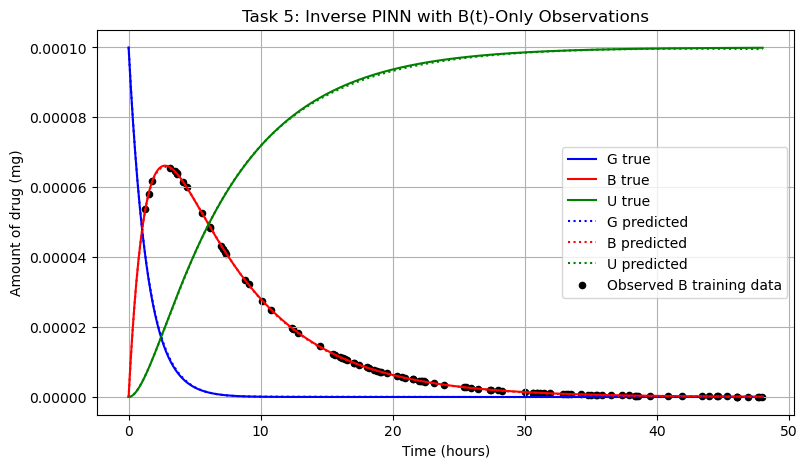

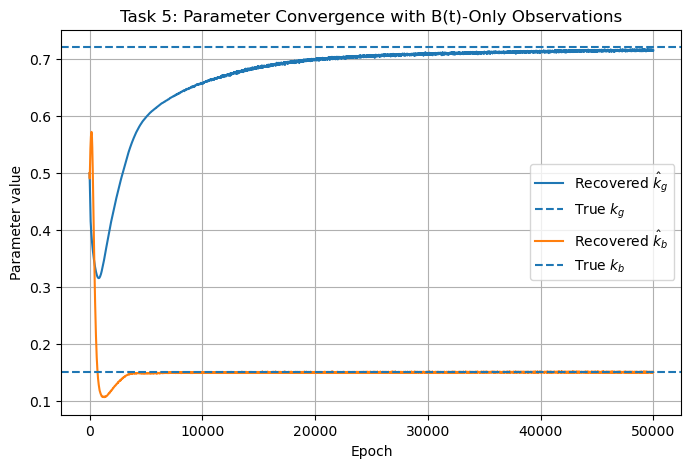

In [81]:
# Training with more epochs since we are only using B(t) observations
B_only_model, B_only_history, B_only_training_time, t_train_B, b_train_norm = train_inverse_pinn_B_only(
    N_data=100,
    N_collocation=1000,
    epochs=50000,
    learning_rate=1e-3,
    print_every=1000,
)

B_only_eval = evaluate_B_only_inverse_model(
    B_only_model,
    t_true_np,
    y_true_np,
    y_true_norm_np
)

print("\nTask 5: B-only inverse PINN results")
print(f"Recovered kg: {B_only_eval['kg_recovered']:.6f} | True kg: {kg:.6f} | Error: {abs(B_only_eval['kg_recovered'] - kg):.3e}")
print(f"Recovered kb: {B_only_eval['kb_recovered']:.6f} | True kb: {kb:.6f} | Error: {abs(B_only_eval['kb_recovered'] - kb):.3e}")
print(f"Full-state normalized MSE: {B_only_eval['test_mse_normalized']:.3e}")
print(f"Full relative L2 error: {B_only_eval['relative_l2_full']:.3e}")
print(f"Training time: {B_only_training_time:.2f} seconds")

y_pred_B_only = B_only_eval["y_pred_physical"]

G_pred = y_pred_B_only[:, 0]
B_pred = y_pred_B_only[:, 1]
U_pred = y_pred_B_only[:, 2]

G_true = y_true_np[:, 0]
B_true = y_true_np[:, 1]
U_true = y_true_np[:, 2]

plt.figure(figsize=(9, 5))

plt.plot(t_true_np, G_true, "b-", label="G true")
plt.plot(t_true_np, B_true, "r-", label="B true")
plt.plot(t_true_np, U_true, "g-", label="U true")

plt.plot(t_true_np, G_pred, "b:", label="G predicted")
plt.plot(t_true_np, B_pred, "r:", label="B predicted")
plt.plot(t_true_np, U_pred, "g:", label="U predicted")

plt.scatter(
    t_train_B.numpy(),
    (G0 * b_train_norm.numpy()),
    color="black",
    s=20,
    label="Observed B training data"
)

plt.xlabel("Time (hours)")
plt.ylabel("Amount of drug (mg)")
plt.title("Task 5: Inverse PINN with B(t)-Only Observations")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(B_only_history["kg"], label=r"Recovered $\hat{k}_g$")
plt.axhline(kg, linestyle="--", label=r"True $k_g$")

plt.plot(B_only_history["kb"], label=r"Recovered $\hat{k}_b$")
plt.axhline(kb, linestyle="--", label=r"True $k_b$")

plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("Task 5: Parameter Convergence with B(t)-Only Observations")
plt.legend()
plt.grid(True)
plt.show()

Using 100 sampled points and 50,000 epochs, we can see that the PINN behavior is matched well in the plot and with a normalized MSE of 2.600e-06. Parameter recovery is accurate as well since the k_g error is 5.745e-03 and the k_b error is 1.426e-04 This proves that even with only B(t) observations, we can still recover the parameters reasonably well by enforcing the physics of the system through the PINN framework.

# Task 6

Adding various levels of gaussian white noise with 0 mean to the synthetic data and studying how uncertainty in the recovered parameters and the forward solution changes using a deep ensemble PINN approach.

In [60]:
# Helper function to sample noisy training data for the inverse PINN

def sample_noisy_training_data(t_true, y_true_norm, N_data, noise_std):
    """
    Sample N_data full-state observations and add Gaussian white noise.

    noise_std is in normalized units.
    Example:
        noise_std = 0.01 means noise with std 1% of G0.
    """
    indices = np.random.choice(len(t_true), size=N_data, replace=False)

    t_data = t_true[indices]
    y_clean_norm = y_true_norm[indices]

    noise = np.random.normal(
        loc=0.0,
        scale=noise_std,
        size=y_clean_norm.shape
    )

    y_noisy_norm = y_clean_norm + noise

    t_data = torch.tensor(t_data, dtype=torch.float32)
    y_noisy_norm = torch.tensor(y_noisy_norm, dtype=torch.float32)

    return t_data, y_noisy_norm

# Same training function as before, but now using the noisy training data

def train_inverse_pinn_noisy(
    N_data=100,
    noise_std=0.01,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
    kg_init=0.5,
    kb_init=0.5
):
    model = InversePharmacokineticPINN(
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=kg_init,
        kb_init=kb_init
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, y_data_noisy_norm = sample_noisy_training_data(
        t_true_np,
        y_true_norm_np,
        N_data=N_data,
        noise_std=noise_std
    )

    history = {
        "total": [],
        "data": [],
        "ode": [],
        "aux": [],
        "kg": [],
        "kb": []
    }

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss, loss_data, loss_ode, loss_aux = inverse_pinn_loss(
            model,
            t_data,
            y_data_noisy_norm,
            t_col,
            t_aux,
            y_aux_norm,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_aux=10.0
        )

        loss.backward()
        optimizer.step()

        kg_current = model.kg_hat.item()
        kb_current = model.kb_hat.item()

        history["total"].append(loss.item())
        history["data"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())
        history["kg"].append(kg_current)
        history["kb"].append(kb_current)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.3e} | "
                f"Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Aux: {loss_aux.item():.3e} | "
                f"kg: {kg_current:.5f} | "
                f"kb: {kb_current:.5f}"
            )

    training_time = time.time() - start_time

    return model, history, training_time, t_data, y_data_noisy_norm

# Training function for the inverse PINN with noisy data

def train_inverse_pinn_noisy(
    N_data=100,
    noise_std=0.01,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
    kg_init=0.5,
    kb_init=0.5
):
    model = InversePharmacokineticPINN(
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=kg_init,
        kb_init=kb_init
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, y_data_noisy_norm = sample_noisy_training_data(
        t_true_np,
        y_true_norm_np,
        N_data=N_data,
        noise_std=noise_std
    )

    history = {
        "total": [],
        "data": [],
        "ode": [],
        "aux": [],
        "kg": [],
        "kb": []
    }

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss, loss_data, loss_ode, loss_aux = inverse_pinn_loss(
            model,
            t_data,
            y_data_noisy_norm,
            t_col,
            t_aux,
            y_aux_norm,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_aux=10.0
        )

        loss.backward()
        optimizer.step()

        kg_current = model.kg_hat.item()
        kb_current = model.kb_hat.item()

        history["total"].append(loss.item())
        history["data"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())
        history["kg"].append(kg_current)
        history["kb"].append(kb_current)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.3e} | "
                f"Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Aux: {loss_aux.item():.3e} | "
                f"kg: {kg_current:.5f} | "
                f"kb: {kb_current:.5f}"
            )

    training_time = time.time() - start_time

    return model, history, training_time, t_data, y_data_noisy_norm

# Helper function to evaluate the inverse PINN model trained on noisy data
def evaluate_inverse_model_for_ensemble(model, t_true_np, y_true_np, y_true_norm_np):
    model.eval()

    t_test = torch.tensor(t_true_np, dtype=torch.float32)

    with torch.no_grad():
        y_pred_physical = model(t_test).cpu().numpy()

    test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)

    relative_l2_full = (
        np.linalg.norm(y_pred_physical - y_true_np)
        / np.linalg.norm(y_true_np)
    )

    kg_recovered = model.kg_hat.item()
    kb_recovered = model.kb_hat.item()

    return {
        "kg_recovered": kg_recovered,
        "kb_recovered": kb_recovered,
        "test_mse_physical": test_mse_physical,
        "relative_l2_full": relative_l2_full,
        "y_pred_physical": y_pred_physical
    }

# Main training function to train a deep ensemble of inverse PINNs for a given noise level

def train_deep_ensemble_for_noise_level(
    noise_std,
    ensemble_size=5,
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3
):
    ensemble_models = []
    ensemble_histories = []
    ensemble_predictions = []

    kg_values = []
    kb_values = []
    mse_values = []
    rel_l2_values = []
    training_times = []

    for m in range(ensemble_size):
        print(f"\n======================================")
        print(f"Noise std = {noise_std}, ensemble member {m+1}/{ensemble_size}")
        print(f"======================================")

        # Different seed for each ensemble member
        torch.manual_seed(m)
        np.random.seed(m)

        model_m, history_m, time_m, _, _ = train_inverse_pinn_noisy(
            N_data=N_data,
            noise_std=noise_std,
            N_collocation=N_collocation,
            epochs=epochs,
            learning_rate=learning_rate,
            print_every=epochs,
            kg_init=0.5,
            kb_init=0.5
        )

        eval_m = evaluate_inverse_model_for_ensemble(
            model_m,
            t_true_np,
            y_true_np,
            y_true_norm_np
        )

        ensemble_models.append(model_m)
        ensemble_histories.append(history_m)
        ensemble_predictions.append(eval_m["y_pred_physical"])

        kg_values.append(eval_m["kg_recovered"])
        kb_values.append(eval_m["kb_recovered"])
        mse_values.append(eval_m["test_mse_physical"])
        rel_l2_values.append(eval_m["relative_l2_full"])
        training_times.append(time_m)

        print(f"Recovered kg: {eval_m['kg_recovered']:.6f}")
        print(f"Recovered kb: {eval_m['kb_recovered']:.6f}")
        print(f"MSE:          {eval_m['test_mse_physical']:.3e}")
        print(f"Time:         {time_m:.2f} seconds")

    ensemble_predictions = np.array(ensemble_predictions)
    kg_values = np.array(kg_values)
    kb_values = np.array(kb_values)
    mse_values = np.array(mse_values)
    rel_l2_values = np.array(rel_l2_values)
    training_times = np.array(training_times)

    y_mean = np.mean(ensemble_predictions, axis=0)
    y_std = np.std(ensemble_predictions, axis=0)

    y_lower = np.percentile(ensemble_predictions, 2.5, axis=0)
    y_upper = np.percentile(ensemble_predictions, 97.5, axis=0)

    return {
        "noise_std": noise_std,

        "models": ensemble_models,
        "histories": ensemble_histories,
        "predictions": ensemble_predictions,

        "kg_values": kg_values,
        "kb_values": kb_values,

        "kg_mean": np.mean(kg_values),
        "kg_std": np.std(kg_values),
        "kg_lower": np.percentile(kg_values, 2.5),
        "kg_upper": np.percentile(kg_values, 97.5),
        "kg_error": abs(np.mean(kg_values) - kg),

        "kb_mean": np.mean(kb_values),
        "kb_std": np.std(kb_values),
        "kb_lower": np.percentile(kb_values, 2.5),
        "kb_upper": np.percentile(kb_values, 97.5),
        "kb_error": abs(np.mean(kb_values) - kb),

        "mse_mean": np.mean(mse_values),
        "mse_std": np.std(mse_values),

        "relative_l2_mean": np.mean(rel_l2_values),
        "relative_l2_std": np.std(rel_l2_values),

        "training_time_mean": np.mean(training_times),
        "training_time_total": np.sum(training_times),

        "y_mean": y_mean,
        "y_std": y_std,
        "y_lower": y_lower,
        "y_upper": y_upper
    }

In [61]:
# Running with noise_std = 0.01 (1% noise) first

ensemble_eval = train_deep_ensemble_for_noise_level(
    noise_std=0.01,
    ensemble_size=10,
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3
)

print("\nDeep Ensemble Results")
print(f"kg mean: {ensemble_eval['kg_mean']:.6f} ± {ensemble_eval['kg_std']:.6f} | true kg: {kg:.6f}")
print(f"kb mean: {ensemble_eval['kb_mean']:.6f} ± {ensemble_eval['kb_std']:.6f} | true kb: {kb:.6f}")
print(f"MSE mean: {ensemble_eval['mse_mean']:.3e} ± {ensemble_eval['mse_std']:.3e}")
print(f"Mean training time: {ensemble_eval['training_time_mean']:.2f} seconds")
print(f"Total ensemble time: {ensemble_eval['training_time_total']:.2f} seconds")


Noise std = 0.01, ensemble member 1/10
Epoch 20000 | Total: 9.399e-05 | Data: 9.013e-05 | ODE: 3.635e-06 | Aux: 2.219e-08 | kg: 0.70926 | kb: 0.14901
Recovered kg: 0.709263
Recovered kb: 0.149013
MSE:          5.510e-14
Time:         32.05 seconds

Noise std = 0.01, ensemble member 2/10
Epoch 20000 | Total: 2.471e-04 | Data: 9.369e-05 | ODE: 1.071e-05 | Aux: 1.427e-05 | kg: 0.72613 | kb: 0.14827
Recovered kg: 0.726126
Recovered kb: 0.148268
MSE:          6.701e-14
Time:         29.54 seconds

Noise std = 0.01, ensemble member 3/10
Epoch 20000 | Total: 1.062e-04 | Data: 1.009e-04 | ODE: 4.650e-06 | Aux: 6.216e-08 | kg: 0.67723 | kb: 0.14995
Recovered kg: 0.677230
Recovered kb: 0.149947
MSE:          1.874e-13
Time:         28.18 seconds

Noise std = 0.01, ensemble member 4/10
Epoch 20000 | Total: 1.084e-04 | Data: 1.042e-04 | ODE: 3.217e-06 | Aux: 1.028e-07 | kg: 0.71312 | kb: 0.15097
Recovered kg: 0.713120
Recovered kb: 0.150974
MSE:          8.165e-14
Time:         27.16 seconds

Noi

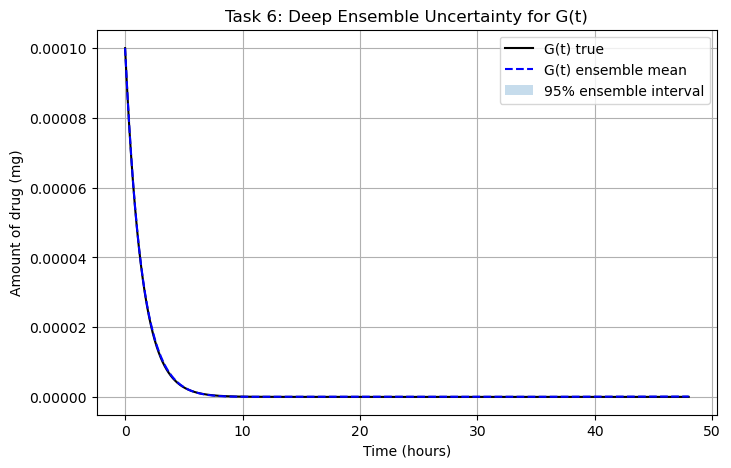

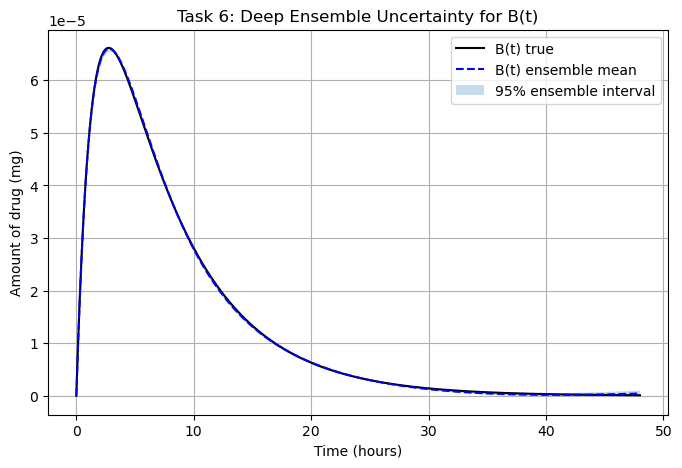

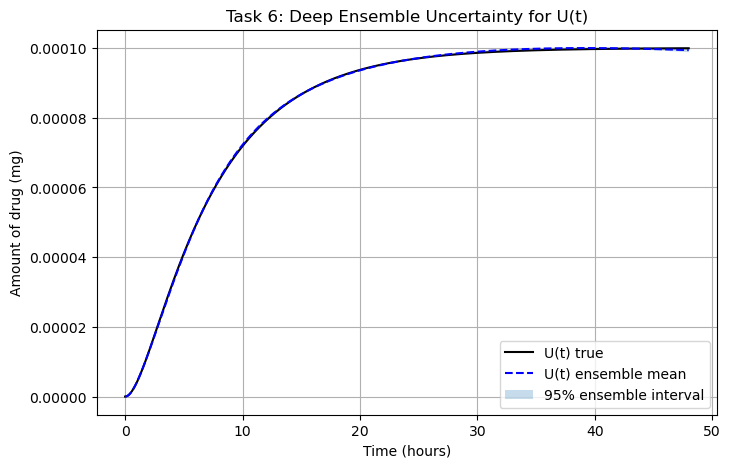

In [62]:
# Plotting the ensemble predictions with uncertainty intervals

t_plot = t_true_np.reshape(-1)

labels = ["G(t)", "B(t)", "U(t)"]

for j, label in enumerate(labels):
    plt.figure(figsize=(8, 5))

    plt.plot(
        t_plot,
        y_true_np[:, j],
        "k-",
        label=f"{label} true"
    )

    plt.plot(
        t_plot,
        ensemble_eval["y_mean"][:, j],
        "b--",
        label=f"{label} ensemble mean"
    )

    plt.fill_between(
        t_plot,
        ensemble_eval["y_lower"][:, j],
        ensemble_eval["y_upper"][:, j],
        alpha=0.25,
        label="95% ensemble interval"
    )

    plt.xlabel("Time (hours)")
    plt.ylabel("Amount of drug (mg)")
    plt.title(f"Task 6: Deep Ensemble Uncertainty for {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

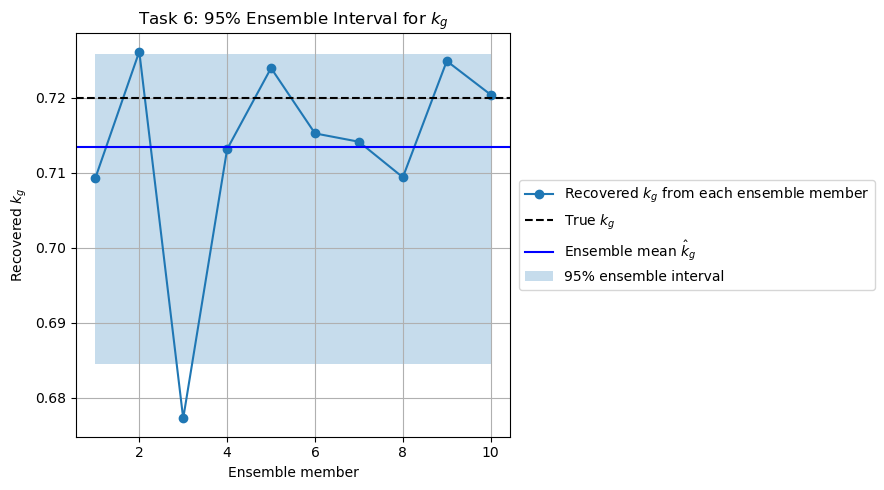

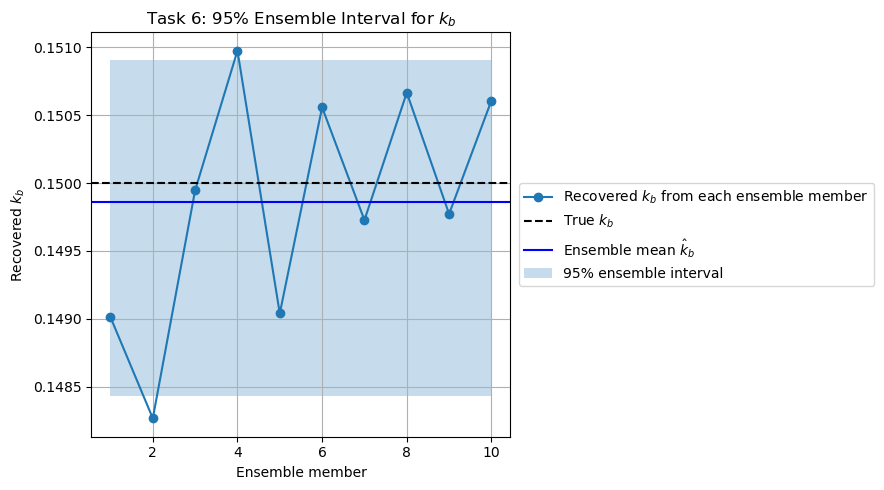

In [63]:
# Plotting recovered parameter values from ensemble with uncertainty intervals

kg_values = ensemble_eval["kg_values"]
kb_values = ensemble_eval["kb_values"]

kg_mean = ensemble_eval["kg_mean"]
kg_std = ensemble_eval["kg_std"]
kg_lower = ensemble_eval["kg_lower"]
kg_upper = ensemble_eval["kg_upper"]

kb_mean = ensemble_eval["kb_mean"]
kb_std = ensemble_eval["kb_std"]
kb_lower = ensemble_eval["kb_lower"]
kb_upper = ensemble_eval["kb_upper"]

ensemble_indices = np.arange(1, len(kg_values) + 1)

# kg plot
plt.figure(figsize=(9, 5))

plt.plot(
    ensemble_indices,
    kg_values,
    "o-",
    label=r"Recovered $k_g$ from each ensemble member"
)

plt.axhline(kg, linestyle="--", color="black", label=r"True $k_g$")
plt.axhline(kg_mean, linestyle="-", color="blue", label=r"Ensemble mean $\hat{k}_g$")

plt.fill_between(
    ensemble_indices,
    kg_lower,
    kg_upper,
    alpha=0.25,
    label="95% ensemble interval"
)

plt.xlabel("Ensemble member")
plt.ylabel(r"Recovered $k_g$")
plt.title(r"Task 6: 95% Ensemble Interval for $k_g$")
plt.grid(True)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()


# kb plot
plt.figure(figsize=(9, 5))

plt.plot(
    ensemble_indices,
    kb_values,
    "o-",
    label=r"Recovered $k_b$ from each ensemble member"
)

plt.axhline(kb, linestyle="--", color="black", label=r"True $k_b$")
plt.axhline(kb_mean, linestyle="-", color="blue", label=r"Ensemble mean $\hat{k}_b$")

plt.fill_between(
    ensemble_indices,
    kb_lower,
    kb_upper,
    alpha=0.25,
    label="95% ensemble interval"
)

plt.xlabel("Ensemble member")
plt.ylabel(r"Recovered $k_b$")
plt.title(r"Task 6: 95% Ensemble Interval for $k_b$")
plt.grid(True)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Running a sweep with different noise levels (0%, 1%, 2%, 5%, 10%, and 20%) and plotting the recovered parameters with uncertainty intervals for each noise level.

In [64]:
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2]

task6_results = []
task6_ensembles = {}

ensemble_size = 5
N_data = 100
N_collocation = 1000
epochs = 20000
learning_rate = 1e-3

for noise_std in noise_levels:
    print(f"\n######################################")
    print(f"Running ensemble for noise_std = {noise_std}")
    print(f"######################################")

    eval_noise = train_deep_ensemble_for_noise_level(
        noise_std=noise_std,
        ensemble_size=ensemble_size,
        N_data=N_data,
        N_collocation=N_collocation,
        epochs=epochs,
        learning_rate=learning_rate
    )

    # Save full object so we can plot trajectories later
    task6_ensembles[noise_std] = eval_noise

    task6_results.append({
        "noise_std": noise_std,

        "kg_mean": eval_noise["kg_mean"],
        "kg_std": eval_noise["kg_std"],
        "kg_lower": eval_noise["kg_lower"],
        "kg_upper": eval_noise["kg_upper"],
        "kg_error": eval_noise["kg_error"],

        "kb_mean": eval_noise["kb_mean"],
        "kb_std": eval_noise["kb_std"],
        "kb_lower": eval_noise["kb_lower"],
        "kb_upper": eval_noise["kb_upper"],
        "kb_error": eval_noise["kb_error"],

        "mse_mean": eval_noise["mse_mean"],
        "mse_std": eval_noise["mse_std"],

        "relative_l2_mean": eval_noise["relative_l2_mean"],
        "relative_l2_std": eval_noise["relative_l2_std"],

        "training_time_mean": eval_noise["training_time_mean"],
        "training_time_total": eval_noise["training_time_total"]
    })

task6_df = pd.DataFrame(task6_results)
task6_df


######################################
Running ensemble for noise_std = 0.0
######################################

Noise std = 0.0, ensemble member 1/5
Epoch 20000 | Total: 7.970e-06 | Data: 4.108e-06 | ODE: 3.226e-06 | Aux: 6.363e-08 | kg: 0.71477 | kb: 0.14981
Recovered kg: 0.714772
Recovered kb: 0.149811
MSE:          3.935e-14
Time:         26.83 seconds

Noise std = 0.0, ensemble member 2/5
Epoch 20000 | Total: 8.620e-06 | Data: 1.698e-06 | ODE: 3.636e-06 | Aux: 3.286e-07 | kg: 0.71739 | kb: 0.14996
Recovered kg: 0.717392
Recovered kb: 0.149957
MSE:          1.889e-14
Time:         26.65 seconds

Noise std = 0.0, ensemble member 3/5
Epoch 20000 | Total: 1.764e-05 | Data: 6.543e-06 | ODE: 5.304e-06 | Aux: 5.794e-07 | kg: 0.69133 | kb: 0.14921
Recovered kg: 0.691326
Recovered kb: 0.149213
MSE:          1.033e-13
Time:         26.63 seconds

Noise std = 0.0, ensemble member 4/5
Epoch 20000 | Total: 6.779e-06 | Data: 3.874e-06 | ODE: 2.808e-06 | Aux: 9.708e-09 | kg: 0.71627 | kb: 0.

,noise_std,kg_mean,kg_std,kg_lower,kg_upper,kg_error,kb_mean,kb_std,kb_lower,kb_upper,kb_error,mse_mean,mse_std,relative_l2_mean,relative_l2_std,training_time_mean,training_time_total
0,0.00,0.711115,0.009930,0.693670,0.717280,0.008885,0.149770,0.000287,0.149273,0.150005,0.000230,5.651057e-14,2.833506e-14,0.004360,0.001163,26.701515,133.507576
1,0.01,0.709934,0.017540,0.680434,0.725906,0.010066,0.149448,0.000930,0.148342,0.150872,0.000552,9.300013e-14,4.800669e-14,0.005634,0.001331,26.474829,132.374144
2,0.02,0.708565,0.025379,0.668140,0.734662,0.011435,0.149100,0.001836,0.146912,0.151881,0.000900,1.805720e-13,8.966372e-14,0.007866,0.001789,26.669938,133.349689
3,0.05,0.705509,0.050683,0.629357,0.761286,0.014491,0.147945,0.004301,0.142470,0.153750,0.002055,7.144364e-13,3.233303e-13,0.015662,0.003486,27.078122,135.390610
4,0.10,0.701346,0.090597,0.572181,0.805814,0.018654,0.145606,0.007950,0.135283,0.156365,0.004394,2.612209e-12,1.002743e-12,0.030134,0.005769,26.632211,133.161054
5,0.20,0.691013,0.167909,0.467670,0.897880,0.028987,0.138286,0.012084,0.121587,0.153106,0.011714,1.222006e-11,5.093017e-12,0.064733,0.014599,26.776635,133.883174


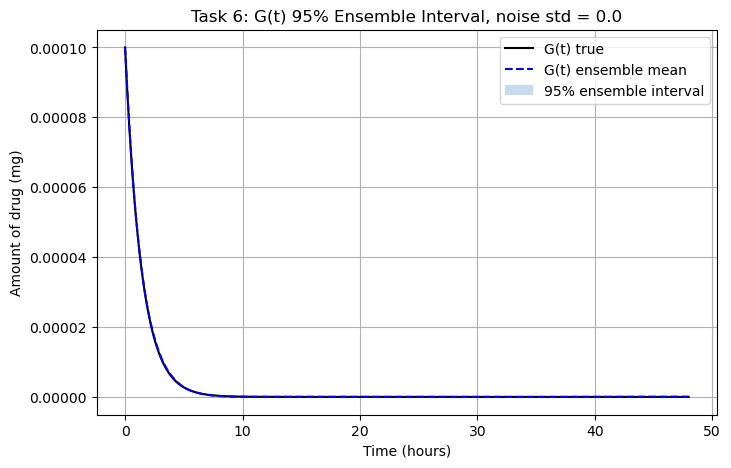

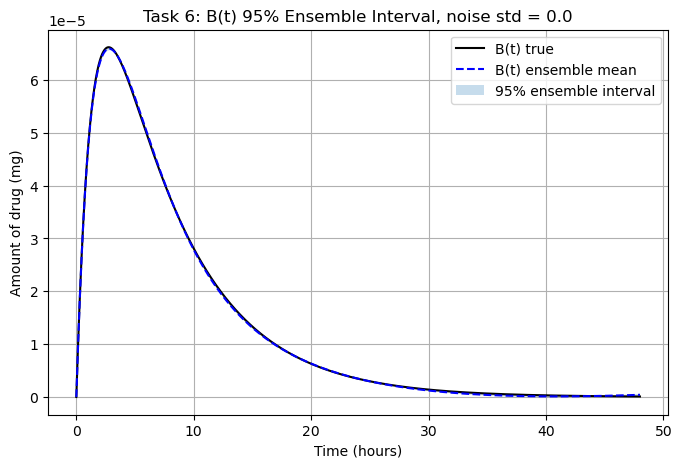

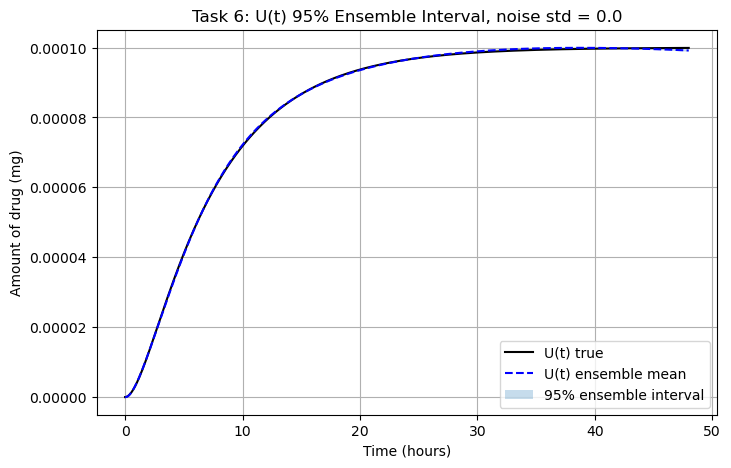

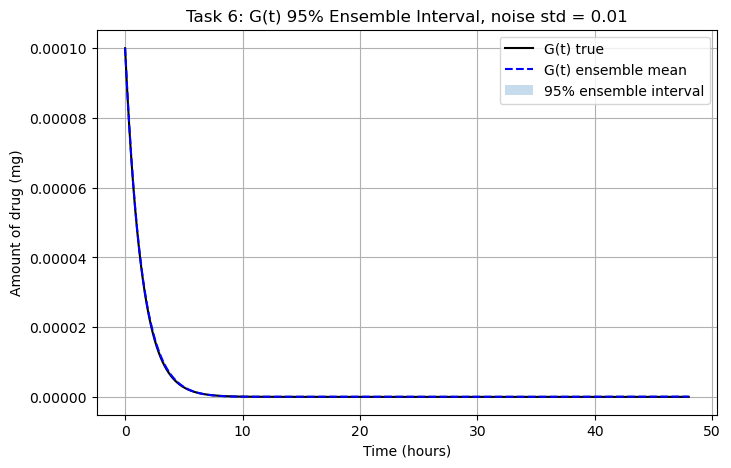

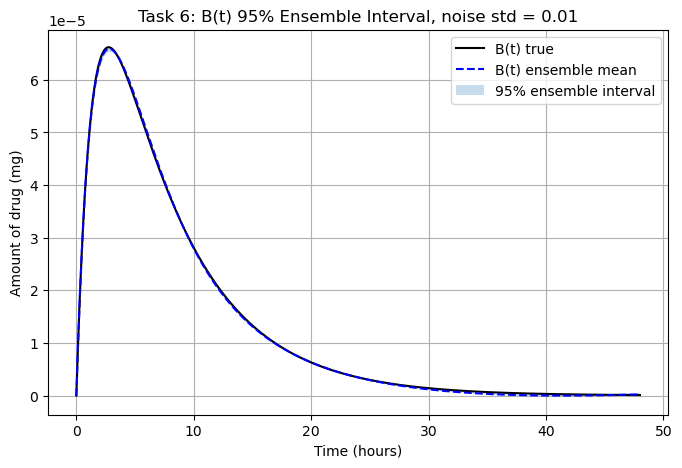

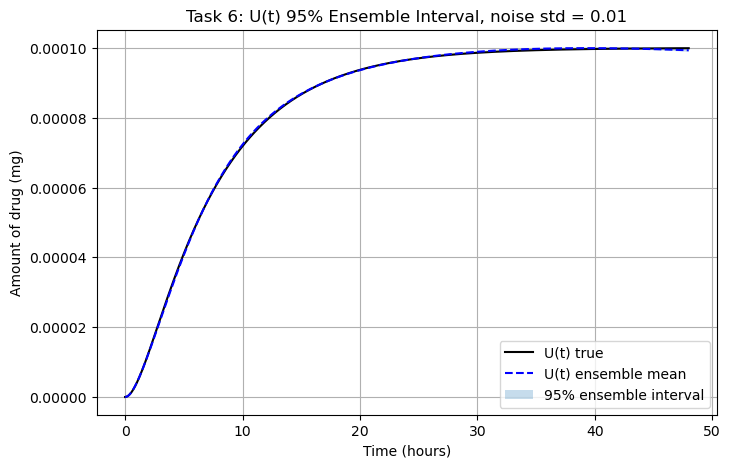

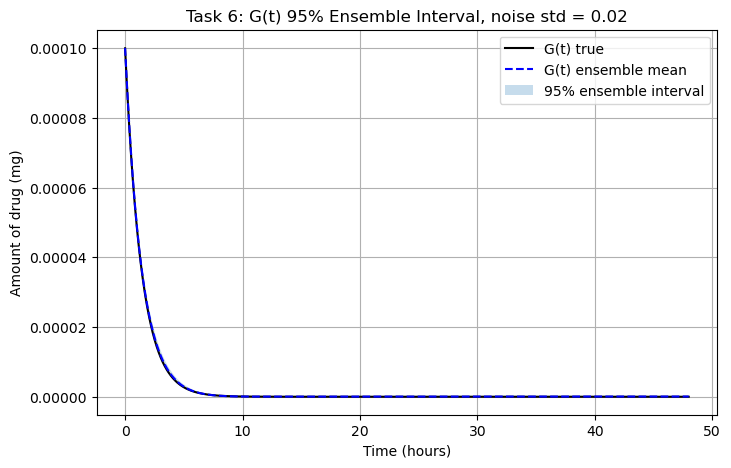

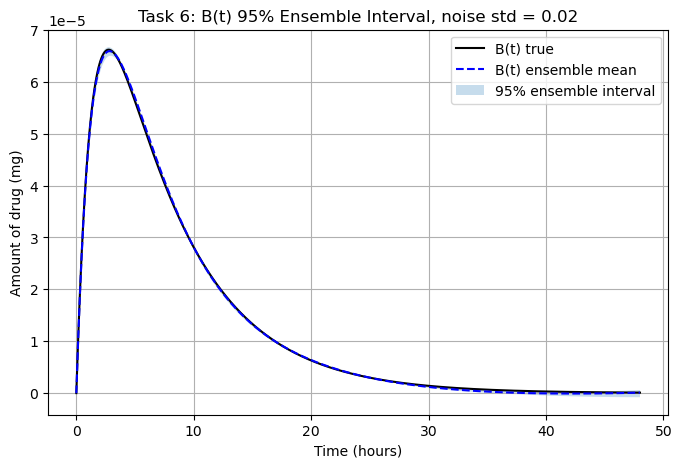

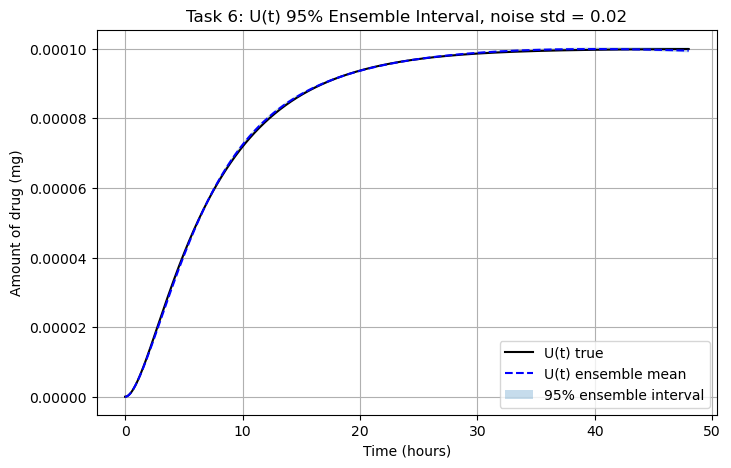

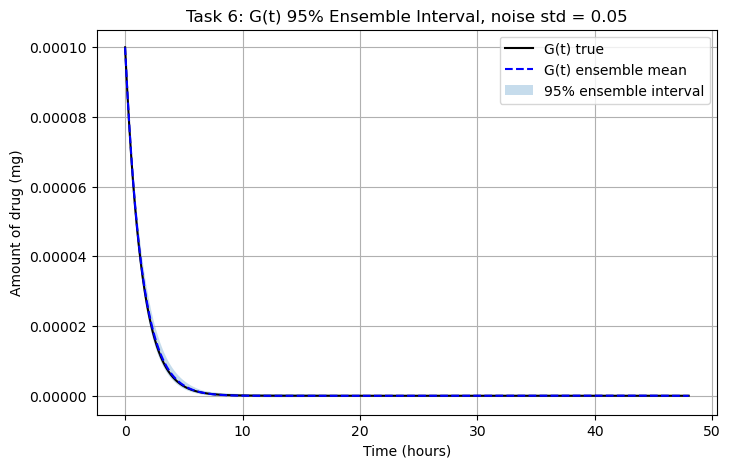

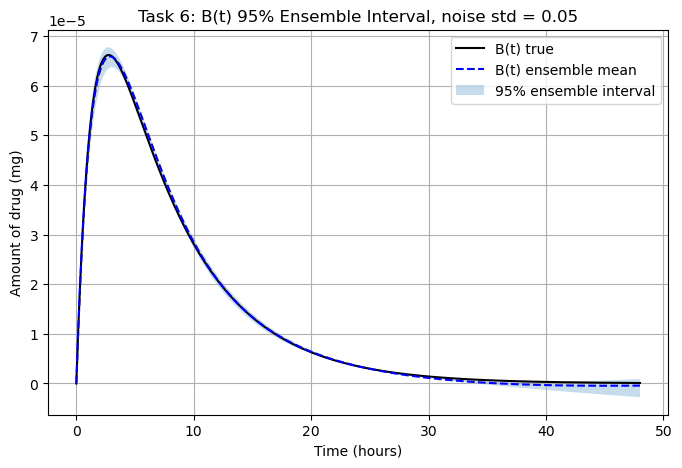

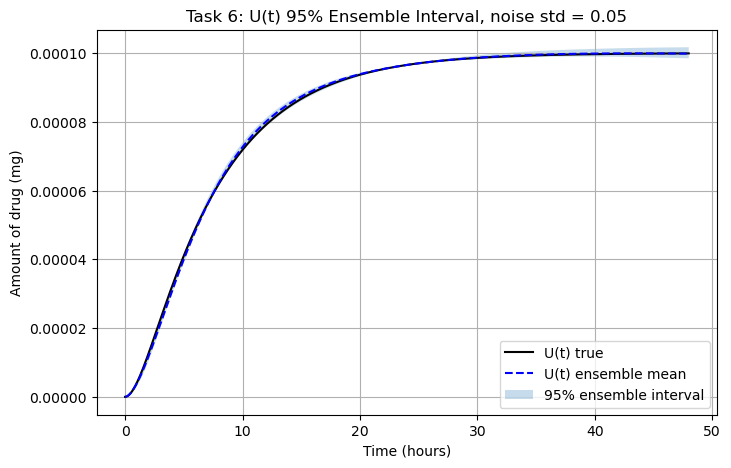

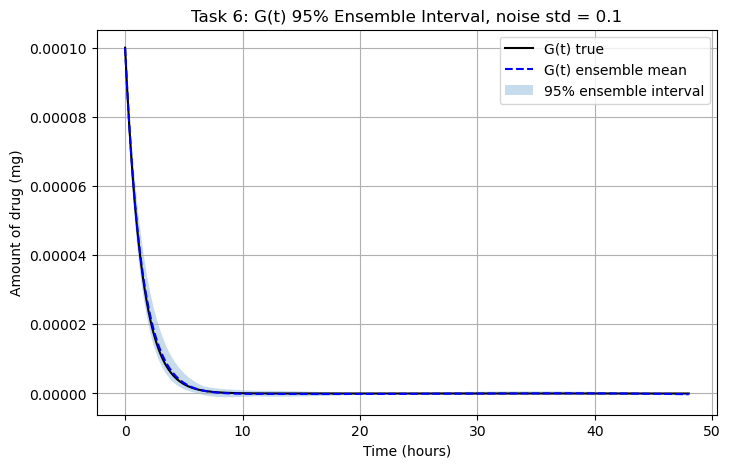

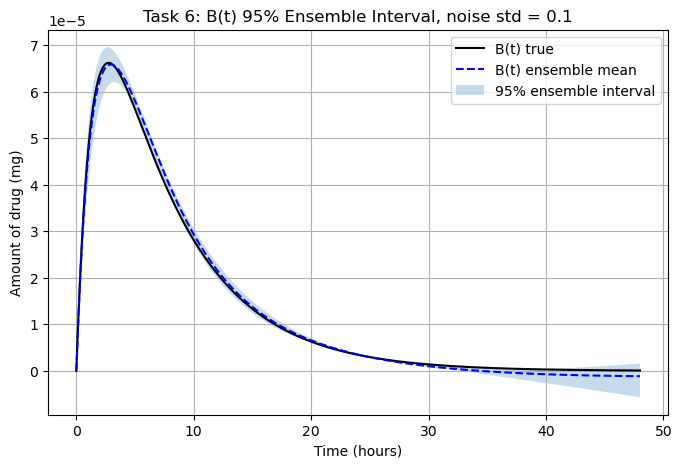

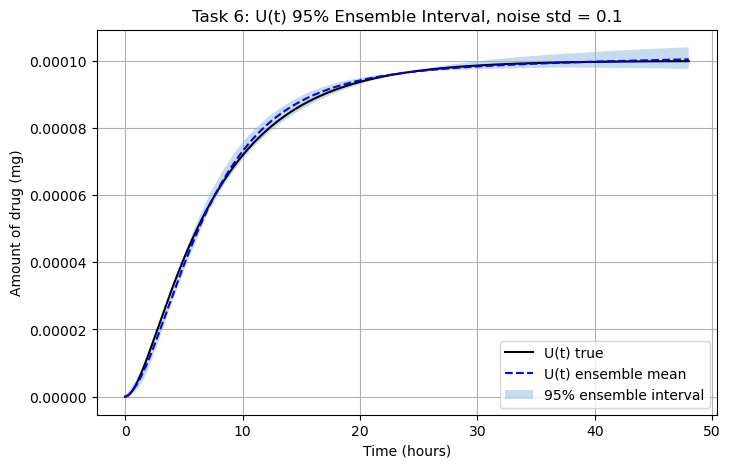

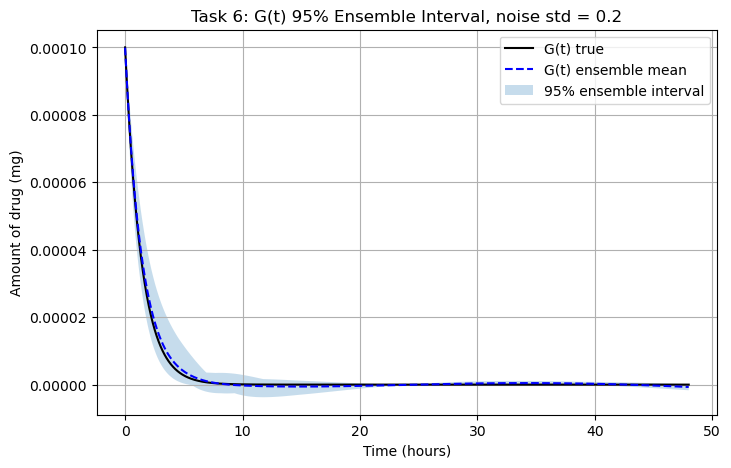

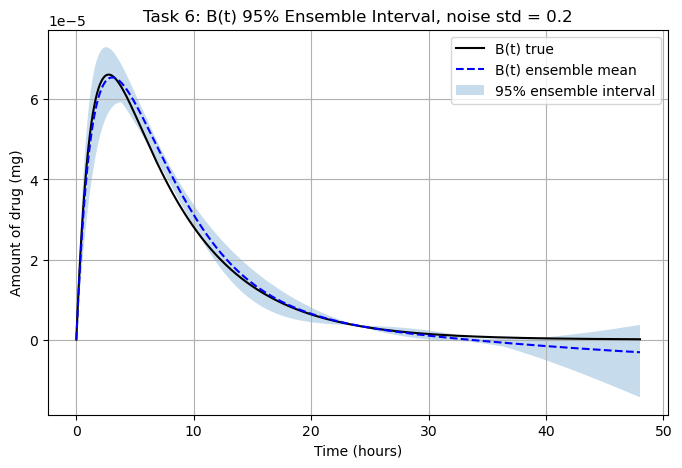

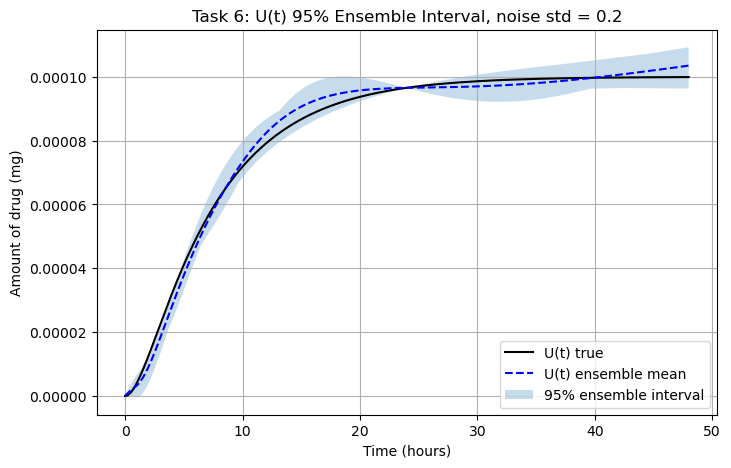

In [65]:
# Plot trajectories of G, B, U with ensemble uncertainty intervals for each noise level

t_plot = t_true_np.reshape(-1)

state_labels = ["G(t)", "B(t)", "U(t)"]

for noise_std, eval_noise in task6_ensembles.items():
    for j, label in enumerate(state_labels):
        plt.figure(figsize=(8, 5))

        plt.plot(
            t_plot,
            y_true_np[:, j],
            "k-",
            label=f"{label} true"
        )

        plt.plot(
            t_plot,
            eval_noise["y_mean"][:, j],
            "b--",
            label=f"{label} ensemble mean"
        )

        plt.fill_between(
            t_plot,
            eval_noise["y_lower"][:, j],
            eval_noise["y_upper"][:, j],
            alpha=0.25,
            label="95% ensemble interval"
        )

        plt.xlabel("Time (hours)")
        plt.ylabel("Amount of drug (mg)")
        plt.title(f"Task 6: {label} 95% Ensemble Interval, noise std = {noise_std}")
        plt.legend(loc="best")
        plt.grid(True)
        plt.show()

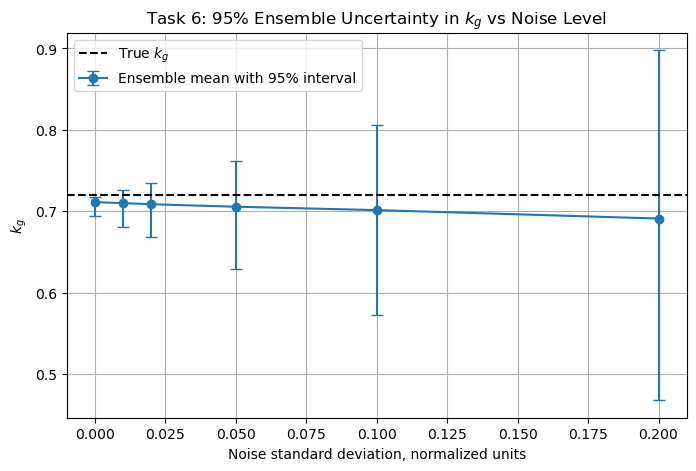

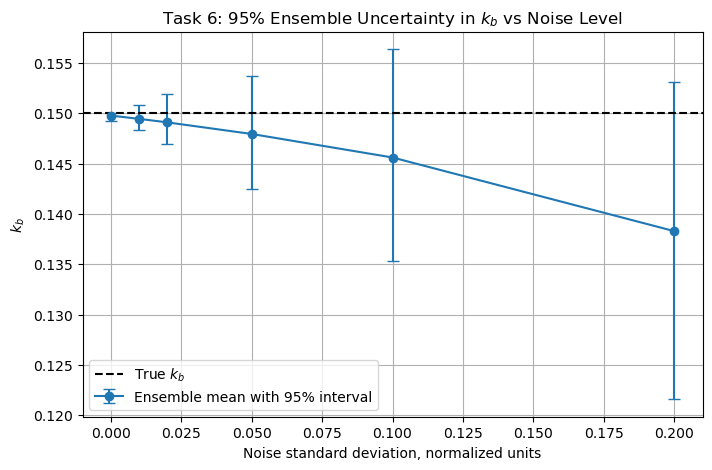

In [66]:
# Plotting recovered kg values with 95% ensemble intervals vs noise level
kg_yerr_lower = task6_df["kg_mean"] - task6_df["kg_lower"]
kg_yerr_upper = task6_df["kg_upper"] - task6_df["kg_mean"]

plt.figure(figsize=(8, 5))

plt.errorbar(
    task6_df["noise_std"],
    task6_df["kg_mean"],
    yerr=[kg_yerr_lower, kg_yerr_upper],
    marker="o",
    capsize=4,
    label="Ensemble mean with 95% interval"
)

plt.axhline(kg, linestyle="--", color="black", label=r"True $k_g$")

plt.xlabel("Noise standard deviation, normalized units")
plt.ylabel(r"$k_g$")
plt.title(r"Task 6: 95% Ensemble Uncertainty in $k_g$ vs Noise Level")
plt.legend()
plt.grid(True)
plt.show()

# Plotting recovered kb values with 95% ensemble intervals vs noise level
kb_yerr_lower = task6_df["kb_mean"] - task6_df["kb_lower"]
kb_yerr_upper = task6_df["kb_upper"] - task6_df["kb_mean"]

plt.figure(figsize=(8, 5))

plt.errorbar(
    task6_df["noise_std"],
    task6_df["kb_mean"],
    yerr=[kb_yerr_lower, kb_yerr_upper],
    marker="o",
    capsize=4,
    label="Ensemble mean with 95% interval"
)

plt.axhline(kb, linestyle="--", color="black", label=r"True $k_b$")

plt.xlabel("Noise standard deviation, normalized units")
plt.ylabel(r"$k_b$")
plt.title(r"Task 6: 95% Ensemble Uncertainty in $k_b$ vs Noise Level")
plt.legend()
plt.grid(True)
plt.show()

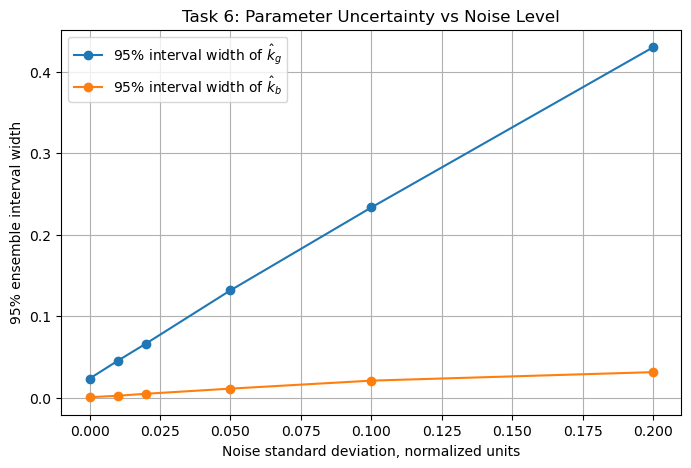

In [67]:
# Plotting the width of the 95% ensemble intervals for kg and kb vs noise level
kg_interval_width = task6_df["kg_upper"] - task6_df["kg_lower"]
kb_interval_width = task6_df["kb_upper"] - task6_df["kb_lower"]

plt.figure(figsize=(8, 5))

plt.plot(
    task6_df["noise_std"],
    kg_interval_width,
    marker="o",
    label=r"95% interval width of $\hat{k}_g$"
)

plt.plot(
    task6_df["noise_std"],
    kb_interval_width,
    marker="o",
    label=r"95% interval width of $\hat{k}_b$"
)

plt.xlabel("Noise standard deviation, normalized units")
plt.ylabel("95% ensemble interval width")
plt.title("Task 6: Parameter Uncertainty vs Noise Level")
plt.legend()
plt.grid(True)
plt.show()

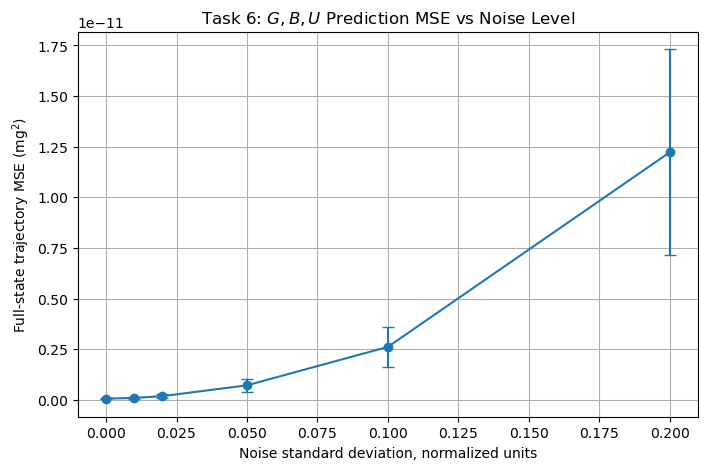

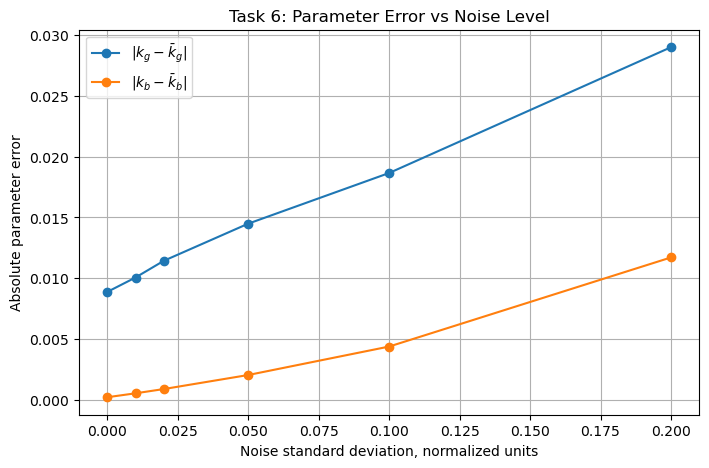

In [68]:
# Plot the MSE of the full-state trajectory predictions vs noise level, with error bars for the std across ensemble members
plt.figure(figsize=(8, 5))

plt.errorbar(
    task6_df["noise_std"],
    task6_df["mse_mean"],
    yerr=task6_df["mse_std"],
    marker="o",
    capsize=4
)

plt.xlabel("Noise standard deviation, normalized units")
plt.ylabel(r"Full-state trajectory MSE (mg$^2$)")
plt.title(r"Task 6: $G,B,U$ Prediction MSE vs Noise Level")
plt.grid(True)
plt.show()

# Plotting the absolute error in recovered parameters vs noise level
plt.figure(figsize=(8, 5))

plt.plot(
    task6_df["noise_std"],
    task6_df["kg_error"],
    marker="o",
    label=r"$|k_g-\bar{k}_g|$"
)

plt.plot(
    task6_df["noise_std"],
    task6_df["kb_error"],
    marker="o",
    label=r"$|k_b-\bar{k}_b|$"
)

plt.xlabel("Noise standard deviation, normalized units")
plt.ylabel("Absolute parameter error")
plt.title("Task 6: Parameter Error vs Noise Level")
plt.legend()
plt.grid(True)
plt.show()

Overall from these results, we see that adding noise to the training data increases uncertainty proportionally to the noise level, which is expected. However, even with 20% noise, the recovered parameters still have reasonable uncertainty intervals that include the true parameter values, which shows that the PINN framework is robust to noise in the data. We can also see that in the trajectories of G(t), B(t), and U(t), the predicted value at T=24 hours is the most certain with very tight uncertainty intervals, which is expected since we are using the value at T=24 hours in the auxiliary loss to help guide the training. 

# Task 7

Solving the inverse problem now using PINNs with an adaptive tanh activation function with 3 different initial slope parameters.

In [69]:
class AdaptiveTanh(nn.Module):
    """
    Adaptive tanh activation:

        phi(x) = tanh(a * x)

    where a is a trainable scalar parameter.
    """
    def __init__(self, sigma_init=1.0):
        super().__init__()
        self.sigma = nn.Parameter(torch.tensor(float(sigma_init), dtype=torch.float32))

    def forward(self, x):
        return torch.tanh(self.sigma * x)
    
# Maintaining the same structure as the previous inverse PINNs, but replacing the activations with AdaptiveTanh
class AdaptiveInversePharmacokineticPINN(nn.Module):
    def __init__(
        self,
        G0=1e-4,
        T=48.0,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=0.5,
        kb_init=0.5,
        sigma_init=1.0
    ):
        super().__init__()

        self.feature_layer = InverseFeatureLayer(T=T)
        self.output_scaling = OutputScalingLayer(G0=G0)

        # Trainable rate parameters
        self.kg_hat = nn.Parameter(torch.tensor([kg_init], dtype=torch.float32))
        self.kb_hat = nn.Parameter(torch.tensor([kb_init], dtype=torch.float32))

        layers = []
        input_dim = 3
        output_dim = 3

        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(AdaptiveTanh(sigma_init=sigma_init))

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(AdaptiveTanh(sigma_init=sigma_init))

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward_normalized(self, t):
        features = self.feature_layer(t)
        y_norm = self.net(features)
        return y_norm

    def forward(self, t):
        y_norm = self.forward_normalized(t)
        y_physical = self.output_scaling(y_norm)
        return y_physical

    def get_activation_sigmas(self):
        """
        Returns the learned adaptive activation parameters.
        """
        sigmas = []
        for layer in self.net:
            if isinstance(layer, AdaptiveTanh):
                sigmas.append(layer.sigma.item())
        return sigmas
    
# Training function for the adaptive inverse PINN
def train_adaptive_inverse_pinn(
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
    kg_init=0.5,
    kb_init=0.5,
    sigma_init=1.0
):
    model = AdaptiveInversePharmacokineticPINN(
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=kg_init,
        kb_init=kb_init,
        sigma_init=sigma_init
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, y_data_norm = sample_training_data(
        t_true_np,
        y_true_norm_np,
        N_data=N_data
    )

    history = {
        "total": [],
        "data": [],
        "ode": [],
        "aux": [],
        "kg": [],
        "kb": [],
        "sigma_mean": [],
        "sigma_values": []
    }

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss, loss_data, loss_ode, loss_aux = inverse_pinn_loss(
            model,
            t_data,
            y_data_norm,
            t_col,
            t_aux,
            y_aux_norm,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_aux=10.0
        )

        loss.backward()
        optimizer.step()

        kg_current = model.kg_hat.item()
        kb_current = model.kb_hat.item()

        sigma_values = model.get_activation_sigmas()
        sigma_mean = np.mean(sigma_values)

        history["total"].append(loss.item())
        history["data"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())
        history["kg"].append(kg_current)
        history["kb"].append(kb_current)
        history["sigma_mean"].append(sigma_mean)
        history["sigma_values"].append(sigma_values)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.3e} | "
                f"Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Aux: {loss_aux.item():.3e} | "
                f"kg: {kg_current:.5f} | "
                f"kb: {kb_current:.5f} | "
                f"mean sigma: {sigma_mean:.5f}"
            )

    training_time = time.time() - start_time

    return model, history, training_time, t_data, y_data_norm

# Evaluation function for the adaptive inverse PINN
def evaluate_adaptive_inverse_model(model, t_true_np, y_true_np, y_true_norm_np):
    model.eval()

    t_test = torch.tensor(t_true_np, dtype=torch.float32)

    with torch.no_grad():
        y_pred_physical = model(t_test).cpu().numpy()

    y_pred_norm = y_pred_physical / G0

    test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)
    test_mse_normalized = np.mean((y_pred_norm - y_true_norm_np) ** 2)

    relative_l2_full = (
        np.linalg.norm(y_pred_physical - y_true_np)
        / np.linalg.norm(y_true_np)
    )

    kg_recovered = model.kg_hat.item()
    kb_recovered = model.kb_hat.item()

    sigma_values = model.get_activation_sigmas()

    return {
        "kg_recovered": kg_recovered,
        "kb_recovered": kb_recovered,
        "kg_error": abs(kg_recovered - kg),
        "kb_error": abs(kb_recovered - kb),
        "test_mse_physical": test_mse_physical,
        "test_mse_normalized": test_mse_normalized,
        "relative_l2_full": relative_l2_full,
        "sigma_values": sigma_values,
        "sigma_mean": np.mean(sigma_values),
        "y_pred_physical": y_pred_physical
    }

In [82]:
# Running adaptive inverse PINN with different initial sigma values
adaptive_sigma_values = [1.0, 2.0, 3.0]

task7_adaptive_results = []

N_data = 100
N_collocation = 1000
epochs = 20000
learning_rate = 1e-3

for sigma_init in adaptive_sigma_values:
    print(f"\n======================================")
    print(f"Adaptive inverse PINN with sigma_init = {sigma_init}")
    print(f"======================================")

    torch.manual_seed(0)
    np.random.seed(0)

    model_sigma, history_sigma, training_time_sigma, t_train_sigma, y_train_sigma = train_adaptive_inverse_pinn(
        N_data=N_data,
        N_collocation=N_collocation,
        epochs=epochs,
        learning_rate=learning_rate,
        print_every=1000,
        kg_init=0.5,
        kb_init=0.5,
        sigma_init=sigma_init
    )

    eval_sigma = evaluate_adaptive_inverse_model(
        model_sigma,
        t_true_np,
        y_true_np,
        y_true_norm_np
    )

    task7_adaptive_results.append({
        "sigma_init": sigma_init,
        "sigma_final_mean": eval_sigma["sigma_mean"],
        "sigma_final_values": eval_sigma["sigma_values"],

        "kg_recovered": eval_sigma["kg_recovered"],
        "kb_recovered": eval_sigma["kb_recovered"],
        "kg_error": eval_sigma["kg_error"],
        "kb_error": eval_sigma["kb_error"],

        "test_mse_physical": eval_sigma["test_mse_physical"],
        "test_mse_normalized": eval_sigma["test_mse_normalized"],
        "relative_l2_full": eval_sigma["relative_l2_full"],

        "training_time": training_time_sigma,
        "model": model_sigma,
        "history": history_sigma,
        "y_pred_physical": eval_sigma["y_pred_physical"]
    })

    print(f"\nResults for sigma_init = {sigma_init}")
    print(f"Recovered kg: {eval_sigma['kg_recovered']:.6f} | True kg: {kg:.6f} | Error: {eval_sigma['kg_error']:.3e}")
    print(f"Recovered kb: {eval_sigma['kb_recovered']:.6f} | True kb: {kb:.6f} | Error: {eval_sigma['kb_error']:.3e}")
    print(f"Final mean sigma: {eval_sigma['sigma_mean']:.6f}")
    print(f"Physical MSE: {eval_sigma['test_mse_physical']:.3e}")
    print(f"Normalized MSE: {eval_sigma['test_mse_normalized']:.3e}")
    print(f"Relative L2 error: {eval_sigma['relative_l2_full']:.3e}")
    print(f"Training time: {training_time_sigma:.2f} seconds")

task7_adaptive_df = pd.DataFrame([
    {
        "sigma_init": r["sigma_init"],
        "sigma_final_mean": r["sigma_final_mean"],
        "kg_recovered": r["kg_recovered"],
        "kb_recovered": r["kb_recovered"],
        "kg_error": r["kg_error"],
        "kb_error": r["kb_error"],
        "test_mse_physical": r["test_mse_physical"],
        "test_mse_normalized": r["test_mse_normalized"],
        "relative_l2_full": r["relative_l2_full"],
        "training_time": r["training_time"]
    }
    for r in task7_adaptive_results
])

task7_adaptive_df


Adaptive inverse PINN with sigma_init = 1.0
Epoch  1000 | Total: 1.753e-02 | Data: 1.494e-02 | ODE: 2.263e-03 | Aux: 3.253e-05 | kg: 0.24820 | kb: 0.29669 | mean sigma: 1.02550
Epoch  2000 | Total: 1.917e-03 | Data: 1.569e-03 | ODE: 3.057e-04 | Aux: 4.286e-06 | kg: 0.44969 | kb: 0.17482 | mean sigma: 1.05816
Epoch  3000 | Total: 3.225e-04 | Data: 2.133e-04 | ODE: 1.047e-04 | Aux: 4.365e-07 | kg: 0.61631 | kb: 0.15393 | mean sigma: 1.06913
Epoch  4000 | Total: 2.480e-04 | Data: 1.404e-04 | ODE: 1.042e-04 | Aux: 3.457e-07 | kg: 0.62896 | kb: 0.14892 | mean sigma: 1.07045
Epoch  5000 | Total: 1.558e-04 | Data: 9.306e-05 | ODE: 5.540e-05 | Aux: 7.298e-07 | kg: 0.63441 | kb: 0.14726 | mean sigma: 1.07219
Epoch  6000 | Total: 1.423e-04 | Data: 5.045e-05 | ODE: 2.579e-05 | Aux: 6.607e-06 | kg: 0.65063 | kb: 0.14733 | mean sigma: 1.07505
Epoch  7000 | Total: 4.905e-05 | Data: 2.873e-05 | ODE: 1.890e-05 | Aux: 1.418e-07 | kg: 0.66895 | kb: 0.14744 | mean sigma: 1.07817
Epoch  8000 | Total: 6.3

,sigma_init,sigma_final_mean,kg_recovered,kb_recovered,kg_error,kb_error,test_mse_physical,test_mse_normalized,relative_l2_full,training_time
0,1.0,1.078276,0.715881,0.149915,0.004119,0.000085,3.617173e-14,3.617182e-06,0.003610,36.979284
1,2.0,2.004799,0.718308,0.150049,0.001692,0.000049,8.657728e-15,8.657769e-07,0.001766,35.605231
2,3.0,2.976324,0.719272,0.150243,0.000728,0.000243,2.024550e-14,2.024578e-06,0.002701,34.707022


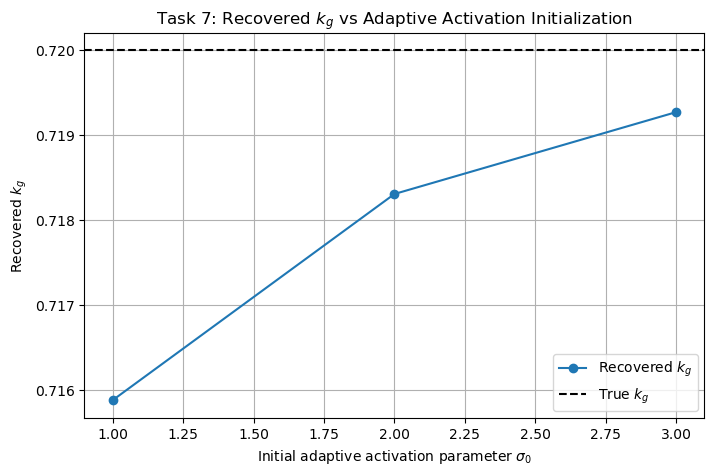

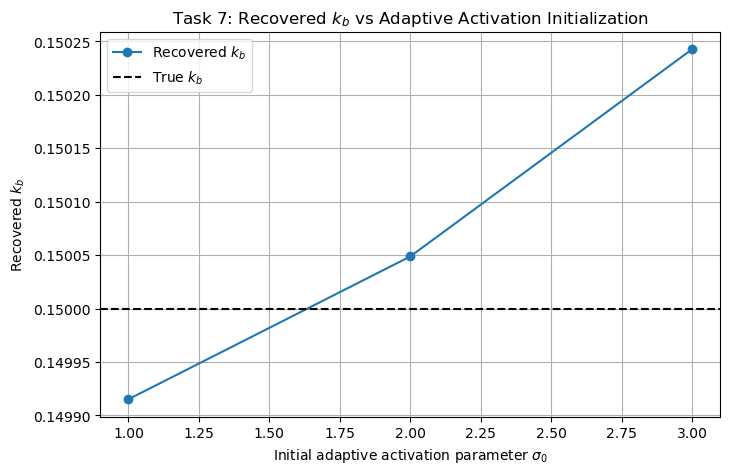

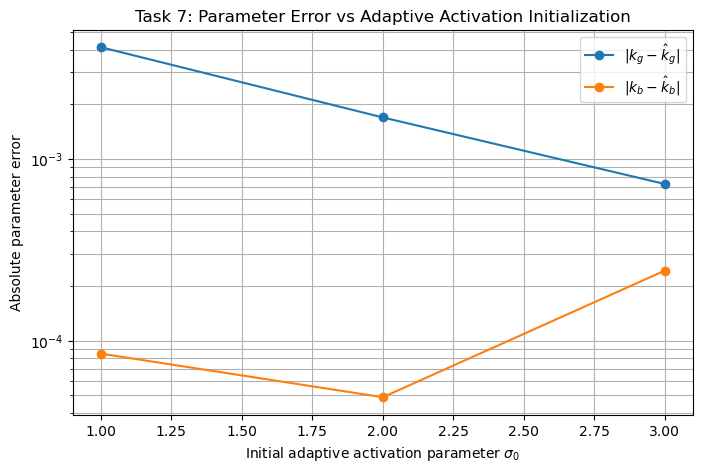

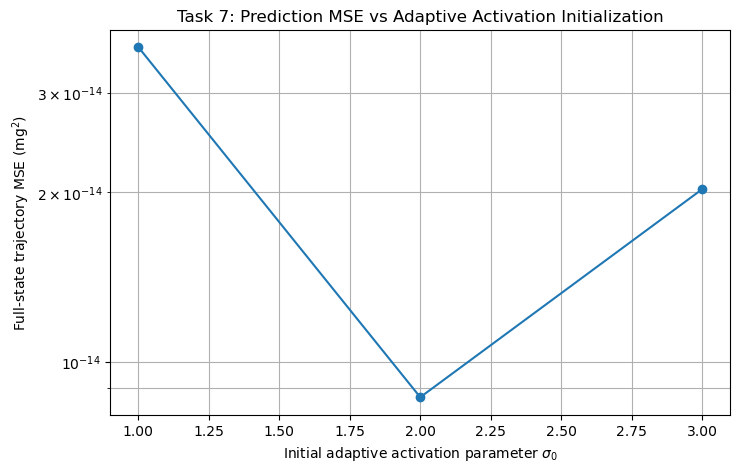

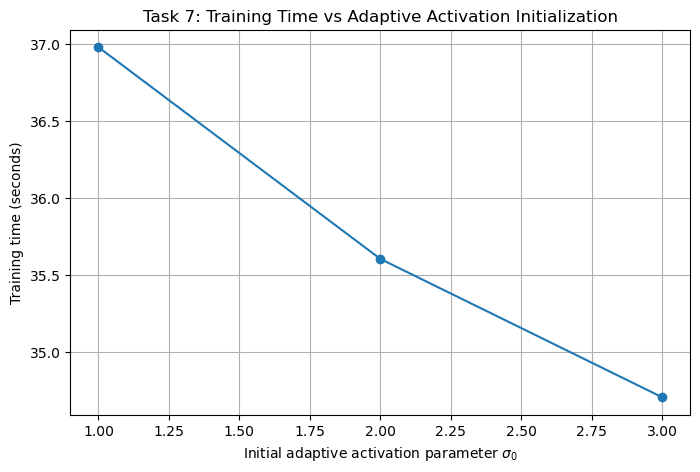

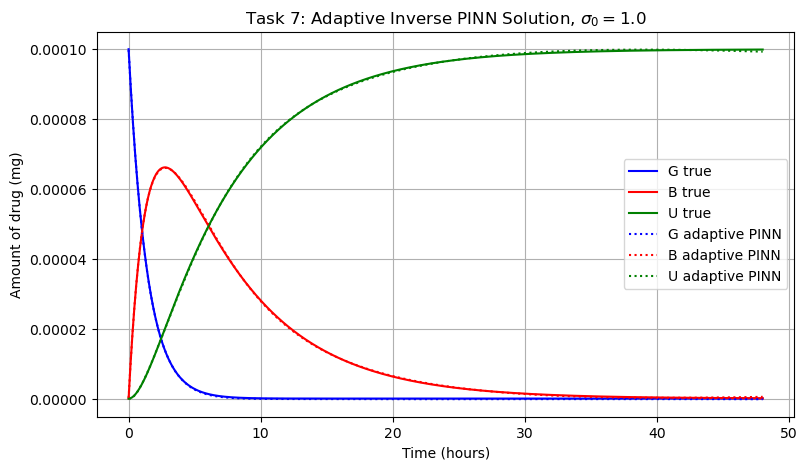

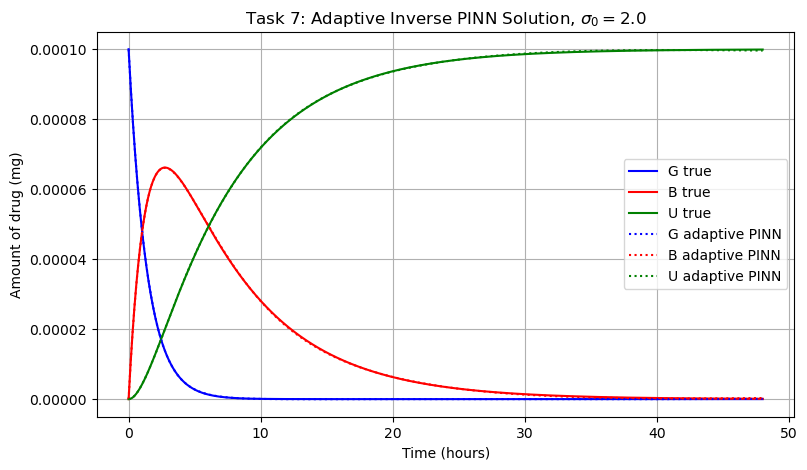

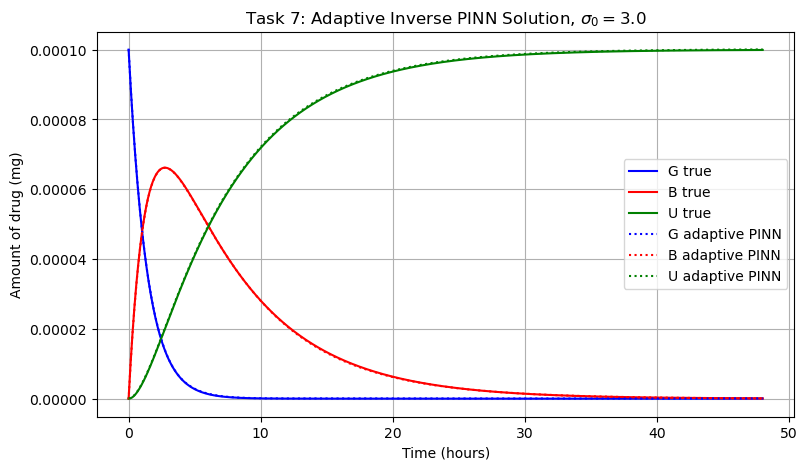

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    task7_adaptive_df["sigma_init"],
    task7_adaptive_df["kg_recovered"],
    marker="o",
    label=r"Recovered $k_g$"
)

plt.axhline(kg, linestyle="--", color="black", label=r"True $k_g$")

plt.xlabel(r"Initial adaptive activation parameter $\sigma_0$")
plt.ylabel(r"Recovered $k_g$")
plt.title(r"Task 7: Recovered $k_g$ vs Adaptive Activation Initialization")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    task7_adaptive_df["sigma_init"],
    task7_adaptive_df["kb_recovered"],
    marker="o",
    label=r"Recovered $k_b$"
)

plt.axhline(kb, linestyle="--", color="black", label=r"True $k_b$")

plt.xlabel(r"Initial adaptive activation parameter $\sigma_0$")
plt.ylabel(r"Recovered $k_b$")
plt.title(r"Task 7: Recovered $k_b$ vs Adaptive Activation Initialization")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.semilogy(
    task7_adaptive_df["sigma_init"],
    task7_adaptive_df["kg_error"],
    marker="o",
    label=r"$|k_g-\hat{k}_g|$"
)

plt.semilogy(
    task7_adaptive_df["sigma_init"],
    task7_adaptive_df["kb_error"],
    marker="o",
    label=r"$|k_b-\hat{k}_b|$"
)

plt.xlabel(r"Initial adaptive activation parameter $\sigma_0$")
plt.ylabel("Absolute parameter error")
plt.title("Task 7: Parameter Error vs Adaptive Activation Initialization")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8, 5))

plt.semilogy(
    task7_adaptive_df["sigma_init"],
    task7_adaptive_df["test_mse_physical"],
    marker="o"
)

plt.xlabel(r"Initial adaptive activation parameter $\sigma_0$")
plt.ylabel(r"Full-state trajectory MSE (mg$^2$)")
plt.title("Task 7: Prediction MSE vs Adaptive Activation Initialization")
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    task7_adaptive_df["sigma_init"],
    task7_adaptive_df["training_time"],
    marker="o"
)

plt.xlabel(r"Initial adaptive activation parameter $\sigma_0$")
plt.ylabel("Training time (seconds)")
plt.title("Task 7: Training Time vs Adaptive Activation Initialization")
plt.grid(True)
plt.show()

t_plot = t_true_np.reshape(-1)

for result in task7_adaptive_results:
    sigma_init = result["sigma_init"]
    y_pred = result["y_pred_physical"]

    plt.figure(figsize=(9, 5))

    plt.plot(t_plot, y_true_np[:, 0], "b-", label="G true")
    plt.plot(t_plot, y_true_np[:, 1], "r-", label="B true")
    plt.plot(t_plot, y_true_np[:, 2], "g-", label="U true")

    plt.plot(t_plot, y_pred[:, 0], "b:", label="G adaptive PINN")
    plt.plot(t_plot, y_pred[:, 1], "r:", label="B adaptive PINN")
    plt.plot(t_plot, y_pred[:, 2], "g:", label="U adaptive PINN")

    plt.xlabel("Time (hours)")
    plt.ylabel("Amount of drug (mg)")
    plt.title(rf"Task 7: Adaptive Inverse PINN Solution, $\sigma_0={sigma_init}$")
    plt.legend()
    plt.grid(True)
    plt.show()

- These are the previous results for the inverse PINN with the same number of sample points, collocation points, and epochs, but with a standard tanh activation function: Recovered kg Error: 3.937e-03, Recovered kb Error: 1.910e-04, Normalized MSE: 3.659e-06, Relative L2 error: 4.636e-03.

- When running with an adaptive activation function with:
    - initial slope parameter of 1.0: Recovered kg Error: 4.119e-03, Recovered kb Error: 8.480e-05, Normalized MSE: 3.617e-06, Relative L2 error: 3.610e-03.
    - initial slope parameter of 2.0: Recovered kg Error: 1.692e-03, Recovered kb Error: 4.881e-05, Normalized MSE: 8.658e-07, Relative L2 error: 1.766e-03.
    - initial slope parameter of 3.0: Recovered kg Error: 7.282e-04, Recovered kb Error: 2.427e-04, Normalized MSE: 2.025e-06, Relative L2 error: 2.701e-03.

- We see generally lower errors when using the adaptive activation function compared to the standard tanh activation function, except for the recovered kg error for the slope parameter of 1.0 which is comparable. In order to distinguish whether the adaptive tanh improvements were due to better problem condition or due to better optimization, we can run experiments using the mean sigma values from the adaptive runs and see how they perform compared to the standard tanh activation function. If we see improvements even with frozen sigma values, then it would suggest that the adaptive tanh is helping with better problem conditioning. If we don't see improvements with frozen sigma values, then it would suggest that the adaptive tanh is helping with better optimization.

In [72]:
# Frozen scaled tanh activation function, where the scaling parameter is fixed and not trainable

class FrozenScaledTanh(nn.Module):
    """
    Frozen scaled tanh activation:

        phi(x) = tanh(sigma * x)
    """
    def __init__(self, sigma=1.0):
        super().__init__()
        self.sigma = float(sigma)

    def forward(self, x):
        return torch.tanh(self.sigma * x)
    
class FrozenSigmaInversePharmacokineticPINN(nn.Module):
    def __init__(
        self,
        G0=1e-4,
        T=48.0,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=0.5,
        kb_init=0.5,
        frozen_sigma=1.0
    ):
        super().__init__()

        self.feature_layer = InverseFeatureLayer(T=T)
        self.output_scaling = OutputScalingLayer(G0=G0)

        # Trainable rate parameters
        self.kg_hat = nn.Parameter(torch.tensor([kg_init], dtype=torch.float32))
        self.kb_hat = nn.Parameter(torch.tensor([kb_init], dtype=torch.float32))

        # Automatically detect number of input features
        with torch.no_grad():
            dummy_t = torch.zeros(1, 1)
            input_dim = self.feature_layer(dummy_t).shape[1]

        output_dim = 3

        layers = []

        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(FrozenScaledTanh(sigma=frozen_sigma))

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(FrozenScaledTanh(sigma=frozen_sigma))

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

        self.frozen_sigma = frozen_sigma

    def forward_normalized(self, t):
        features = self.feature_layer(t)
        y_norm = self.net(features)
        return y_norm

    def forward(self, t):
        y_norm = self.forward_normalized(t)
        y_physical = self.output_scaling(y_norm)
        return y_physical
    
def train_frozen_sigma_inverse_pinn(
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
    kg_init=0.5,
    kb_init=0.5,
    frozen_sigma=1.0
):
    model = FrozenSigmaInversePharmacokineticPINN(
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2,
        kg_init=kg_init,
        kb_init=kb_init,
        frozen_sigma=frozen_sigma
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, y_data_norm = sample_training_data(
        t_true_np,
        y_true_norm_np,
        N_data=N_data
    )

    history = {
        "total": [],
        "data": [],
        "ode": [],
        "aux": [],
        "kg": [],
        "kb": []
    }

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss, loss_data, loss_ode, loss_aux = inverse_pinn_loss(
            model,
            t_data,
            y_data_norm,
            t_col,
            t_aux,
            y_aux_norm,
            lambda_data=1.0,
            lambda_ode=1.0,
            lambda_aux=10.0
        )

        loss.backward()
        optimizer.step()

        kg_current = model.kg_hat.item()
        kb_current = model.kb_hat.item()

        history["total"].append(loss.item())
        history["data"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())
        history["kg"].append(kg_current)
        history["kb"].append(kb_current)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.3e} | "
                f"Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Aux: {loss_aux.item():.3e} | "
                f"kg: {kg_current:.5f} | "
                f"kb: {kb_current:.5f}"
            )

    training_time = time.time() - start_time

    return model, history, training_time, t_data, y_data_norm

def evaluate_frozen_sigma_inverse_model(model, t_true_np, y_true_np, y_true_norm_np):
    model.eval()

    t_test = torch.tensor(t_true_np, dtype=torch.float32)

    with torch.no_grad():
        y_pred_physical = model(t_test).cpu().numpy()

    y_pred_norm = y_pred_physical / G0

    test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)
    test_mse_normalized = np.mean((y_pred_norm - y_true_norm_np) ** 2)

    relative_l2_full = (
        np.linalg.norm(y_pred_physical - y_true_np)
        / np.linalg.norm(y_true_np)
    )

    kg_recovered = model.kg_hat.item()
    kb_recovered = model.kb_hat.item()

    return {
        "kg_recovered": kg_recovered,
        "kb_recovered": kb_recovered,
        "kg_error": abs(kg_recovered - kg),
        "kb_error": abs(kb_recovered - kb),
        "test_mse_physical": test_mse_physical,
        "test_mse_normalized": test_mse_normalized,
        "relative_l2_full": relative_l2_full,
        "y_pred_physical": y_pred_physical
    }

In [85]:
# Run frozen-sigma inverse PINNs using learned sigma values

frozen_sigma_values = [1.078276, 2.004799, 2.976324]

task7_frozen_results = []

N_data = 100
N_collocation = 1000
epochs = 20000
learning_rate = 1e-3

for frozen_sigma in frozen_sigma_values:
    print(f"\n======================================")
    print(f"Frozen-sigma inverse PINN with sigma = {frozen_sigma}")
    print(f"======================================")

    torch.manual_seed(0)
    np.random.seed(0)

    model_frozen, history_frozen, training_time_frozen, t_train_frozen, y_train_frozen = train_frozen_sigma_inverse_pinn(
        N_data=N_data,
        N_collocation=N_collocation,
        epochs=epochs,
        learning_rate=learning_rate,
        print_every=1000,
        kg_init=0.5,
        kb_init=0.5,
        frozen_sigma=frozen_sigma
    )

    eval_frozen = evaluate_frozen_sigma_inverse_model(
        model_frozen,
        t_true_np,
        y_true_np,
        y_true_norm_np
    )

    task7_frozen_results.append({
        "frozen_sigma": frozen_sigma,

        "kg_recovered": eval_frozen["kg_recovered"],
        "kb_recovered": eval_frozen["kb_recovered"],
        "kg_error": eval_frozen["kg_error"],
        "kb_error": eval_frozen["kb_error"],

        "test_mse_physical": eval_frozen["test_mse_physical"],
        "test_mse_normalized": eval_frozen["test_mse_normalized"],
        "relative_l2_full": eval_frozen["relative_l2_full"],

        "training_time": training_time_frozen,
        "model": model_frozen,
        "history": history_frozen,
        "y_pred_physical": eval_frozen["y_pred_physical"]
    })

    print(f"\nResults for frozen_sigma = {frozen_sigma}")
    print(f"Recovered kg: {eval_frozen['kg_recovered']:.6f} | True kg: {kg:.6f} | Error: {eval_frozen['kg_error']:.3e}")
    print(f"Recovered kb: {eval_frozen['kb_recovered']:.6f} | True kb: {kb:.6f} | Error: {eval_frozen['kb_error']:.3e}")
    print(f"Physical MSE: {eval_frozen['test_mse_physical']:.3e}")
    print(f"Normalized MSE: {eval_frozen['test_mse_normalized']:.3e}")
    print(f"Relative L2 error: {eval_frozen['relative_l2_full']:.3e}")
    print(f"Training time: {training_time_frozen:.2f} seconds")

task7_frozen_df = pd.DataFrame([
    {
        "frozen_sigma": r["frozen_sigma"],
        "kg_recovered": r["kg_recovered"],
        "kb_recovered": r["kb_recovered"],
        "kg_error": r["kg_error"],
        "kb_error": r["kb_error"],
        "test_mse_physical": r["test_mse_physical"],
        "test_mse_normalized": r["test_mse_normalized"],
        "relative_l2_full": r["relative_l2_full"],
        "training_time": r["training_time"]
    }
    for r in task7_frozen_results
])

task7_frozen_df


Frozen-sigma inverse PINN with sigma = 1.078276
Epoch  1000 | Total: 1.637e-02 | Data: 1.403e-02 | ODE: 2.031e-03 | Aux: 3.033e-05 | kg: 0.25440 | kb: 0.30412
Epoch  2000 | Total: 1.759e-03 | Data: 1.446e-03 | ODE: 2.746e-04 | Aux: 3.828e-06 | kg: 0.45581 | kb: 0.17479
Epoch  3000 | Total: 3.216e-04 | Data: 2.135e-04 | ODE: 1.038e-04 | Aux: 4.254e-07 | kg: 0.61409 | kb: 0.15402
Epoch  4000 | Total: 2.527e-04 | Data: 1.434e-04 | ODE: 1.060e-04 | Aux: 3.368e-07 | kg: 0.62833 | kb: 0.14890
Epoch  5000 | Total: 1.616e-04 | Data: 1.008e-04 | ODE: 5.879e-05 | Aux: 2.021e-07 | kg: 0.63318 | kb: 0.14728
Epoch  6000 | Total: 9.228e-05 | Data: 6.227e-05 | ODE: 2.664e-05 | Aux: 3.369e-07 | kg: 0.64763 | kb: 0.14725
Epoch  7000 | Total: 5.892e-05 | Data: 3.064e-05 | ODE: 1.949e-05 | Aux: 8.784e-07 | kg: 0.66603 | kb: 0.14739
Epoch  8000 | Total: 1.229e-04 | Data: 1.958e-05 | ODE: 1.390e-05 | Aux: 8.946e-06 | kg: 0.68209 | kb: 0.14864
Epoch  9000 | Total: 2.999e-05 | Data: 1.337e-05 | ODE: 1.141e-

,frozen_sigma,kg_recovered,kb_recovered,kg_error,kb_error,test_mse_physical,test_mse_normalized,relative_l2_full,training_time
0,1.078276,0.715676,0.150012,0.004324,0.000012,6.669541e-14,6.669566e-06,0.004902,33.686036
1,2.004799,0.716593,0.150102,0.003407,0.000102,1.303298e-14,1.303290e-06,0.002167,31.618389
2,2.976324,0.712138,0.149732,0.007862,0.000268,2.698795e-15,2.698877e-07,0.000986,33.072145


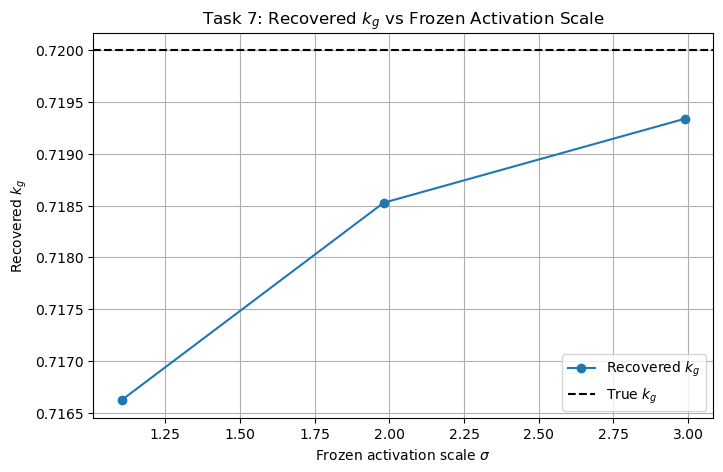

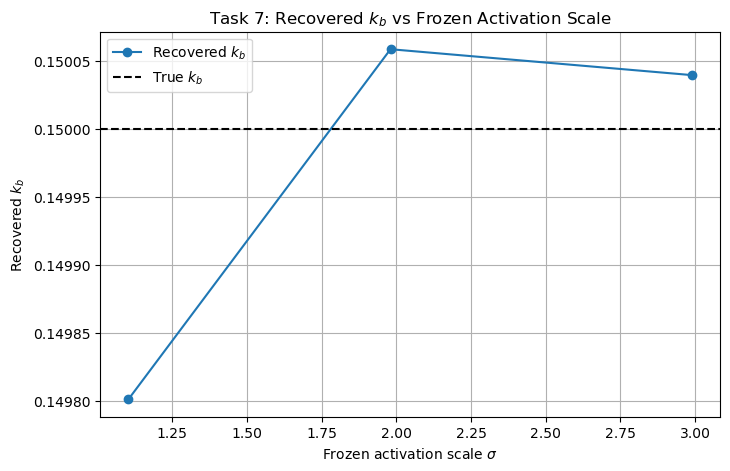

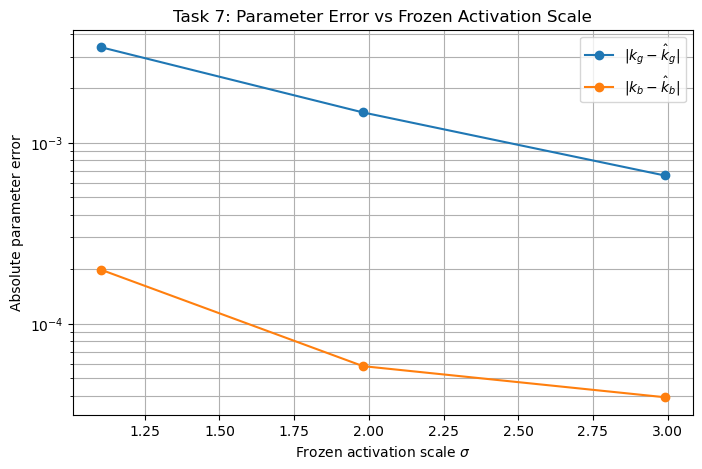

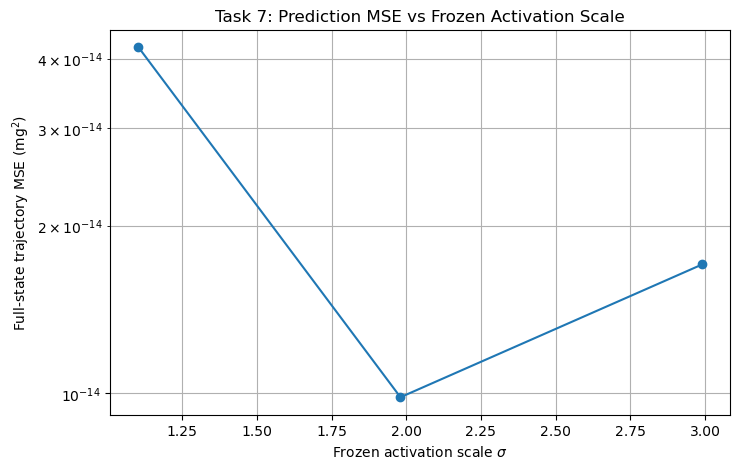

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    task7_frozen_df["frozen_sigma"],
    task7_frozen_df["kg_recovered"],
    marker="o",
    label=r"Recovered $k_g$"
)

plt.axhline(kg, linestyle="--", color="black", label=r"True $k_g$")

plt.xlabel(r"Frozen activation scale $\sigma$")
plt.ylabel(r"Recovered $k_g$")
plt.title(r"Task 7: Recovered $k_g$ vs Frozen Activation Scale")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    task7_frozen_df["frozen_sigma"],
    task7_frozen_df["kb_recovered"],
    marker="o",
    label=r"Recovered $k_b$"
)

plt.axhline(kb, linestyle="--", color="black", label=r"True $k_b$")

plt.xlabel(r"Frozen activation scale $\sigma$")
plt.ylabel(r"Recovered $k_b$")
plt.title(r"Task 7: Recovered $k_b$ vs Frozen Activation Scale")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.semilogy(
    task7_frozen_df["frozen_sigma"],
    task7_frozen_df["kg_error"],
    marker="o",
    label=r"$|k_g-\hat{k}_g|$"
)

plt.semilogy(
    task7_frozen_df["frozen_sigma"],
    task7_frozen_df["kb_error"],
    marker="o",
    label=r"$|k_b-\hat{k}_b|$"
)

plt.xlabel(r"Frozen activation scale $\sigma$")
plt.ylabel("Absolute parameter error")
plt.title("Task 7: Parameter Error vs Frozen Activation Scale")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8, 5))

plt.semilogy(
    task7_frozen_df["frozen_sigma"],
    task7_frozen_df["test_mse_physical"],
    marker="o"
)

plt.xlabel(r"Frozen activation scale $\sigma$")
plt.ylabel(r"Full-state trajectory MSE (mg$^2$)")
plt.title("Task 7: Prediction MSE vs Frozen Activation Scale")
plt.grid(True, which="both")
plt.show()

- Previous results of running with an adaptive activation function with:
    - initial slope parameter of 1.0: Recovered kg Error: 4.119e-03, Recovered kb Error: 8.480e-05, Normalized MSE: 3.617e-06, Relative L2 error: 3.610e-03.
    - initial slope parameter of 2.0: Recovered kg Error: 1.692e-03, Recovered kb Error: 4.881e-05, Normalized MSE: 8.658e-07, Relative L2 error: 1.766e-03.
    - initial slope parameter of 3.0: Recovered kg Error: 7.282e-04, Recovered kb Error: 2.427e-04, Normalized MSE: 2.025e-06, Relative L2 error: 2.701e-03.

- Now, when running with a nonadaptive scaled activation function with the frozen slope parameter mean values from the previous runs:
    - initial slope parameter of 1.078276: Recovered kg Error: 4.324e-03, Recovered kb Error: 1.166e-05, Normalized MSE: 6.670e-06, Relative L2 error: 4.902e-03.
    - initial slope parameter of 2.004799: Recovered kg Error: 3.407e-03, Recovered kb Error: 1.019e-04, Normalized MSE: 1.303e-06, Relative L2 error: 2.167e-03.
    - initial slope parameter of 2.976324: Recovered kg Error: 7.862e-03, Recovered kb Error: 2.683e-04, Normalized MSE: 2.699e-07, Relative L2 error: 9.862e-04.

- The frozen-sigma runs achieved trajectory errors that were comparable to, and in some cases better than, the fully adaptive models. Parameter recovery was more mixed, with adaptive tanh generally giving slightly better kg recovery, but the frozen scaled-tanh models still remained in a similar range which suggests that the improvements we saw with the adaptive tanh were likely due to better problem conditioning rather than better optimization. This indicates that the main benefit is that a larger tanh slope improves the effective representation of the pharmacokinetic trajectories, likely by better matching the fast early decay and slower long-time dynamics. Since the frozen-sigma models preserved or improved the gains without learning σ, the results point more toward improved problem conditioning/representation than toward the adaptive parameter itself acting as an optimizer aid. In the case of parameter recovery though, results are a bit more mixed and it is possible that the adaptive optimization of σ could be providing some additional benefit on top of the improved problem conditioning.

# Task 8

Solving the inverse problem using adaptive loss weighting: 
- Approach 3 from Lecture 8: Dynamic Weights for PINNs

In [100]:
# Task 8: Adaptive Loss Weighting using Gradient-Norm Balancing

def mean_abs_grad(loss, params, retain_graph=True):
    """
    Computes the mean absolute gradient magnitude of a loss
    with respect to a list of parameters.

    Some losses may not depend on all parameters, so allow_unused=True.
    """
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=retain_graph,
        create_graph=False,
        allow_unused=True
    )

    grad_means = []

    for g in grads:
        if g is not None:
            grad_means.append(torch.mean(torch.abs(g.detach())))

    if len(grad_means) == 0:
        return torch.tensor(0.0)

    return torch.mean(torch.stack(grad_means))

def inverse_pinn_loss_components(model, t_data, y_data_norm, t_col, t_aux, y_aux_norm):
    """
    Computes the three unweighted inverse PINN loss components:

        L_data
        L_ode
        L_aux
    """

    # Data loss
    y_pred_data_norm = model.forward_normalized(t_data)
    loss_data = torch.mean((y_pred_data_norm - y_data_norm) ** 2)

    # ODE residual loss
    y_col_norm = model.forward_normalized(t_col)

    g = y_col_norm[:, 0:1]
    b = y_col_norm[:, 1:2]
    u = y_col_norm[:, 2:3]

    dgdt = torch.autograd.grad(
        g,
        t_col,
        grad_outputs=torch.ones_like(g),
        create_graph=True
    )[0]

    dbdt = torch.autograd.grad(
        b,
        t_col,
        grad_outputs=torch.ones_like(b),
        create_graph=True
    )[0]

    dudt = torch.autograd.grad(
        u,
        t_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    kg_hat = model.kg_hat
    kb_hat = model.kb_hat

    r_g = dgdt + kg_hat * g
    r_b = dbdt - kg_hat * g + kb_hat * b
    r_u = dudt - kb_hat * b

    loss_ode = (
        torch.mean(r_g ** 2)
        + torch.mean(r_b ** 2)
        + torch.mean(r_u ** 2)
    )

    # Auxiliary loss
    y_aux_pred_norm = model.forward_normalized(t_aux)
    loss_aux = torch.mean((y_aux_pred_norm - y_aux_norm) ** 2)

    return loss_data, loss_ode, loss_aux

def train_inverse_pinn_dynamic_weights(
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
    beta=0.1,
    lambda_data_init=1.0,
    lambda_aux_init=1.0,
    lambda_min=0.1,
    lambda_max=1000.0,
    update_weights_every=1
):
    """
    Trains an inverse PINN using dynamic loss weighting.

    Loss:
        L = L_ode + lambda_data * L_data + lambda_aux * L_aux

    Dynamic weights:
        lambda_data ≈ mean(|grad L_ode|) / mean(|grad L_data|)
        lambda_aux  ≈ mean(|grad L_ode|) / mean(|grad L_aux|)

    The updates are smoothed using:
        lambda_new = (1 - beta) * lambda_old + beta * lambda_hat
    """

    model = InversePharmacokineticPINN(
        G0=G0,
        T=T_final,
        hidden_dim=32,
        num_hidden_layers=2,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    t_data, y_data_norm = sample_training_data(
        t_true_np,
        y_true_norm_np,
        N_data=N_data
    )

    lambda_data = torch.tensor(float(lambda_data_init))
    lambda_aux = torch.tensor(float(lambda_aux_init))

    history = {
        "total": [],
        "data": [],
        "ode": [],
        "aux": [],

        "lambda_data": [],
        "lambda_aux": [],

        "grad_data": [],
        "grad_ode": [],
        "grad_aux": [],

        "kg": [],
        "kb": []
    }

    eps = 1e-12
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        t_col = sample_collocation_points(N_collocation)

        loss_data, loss_ode, loss_aux = inverse_pinn_loss_components(
            model,
            t_data,
            y_data_norm,
            t_col,
            t_aux,
            y_aux_norm
        )

        params_for_weighting = [p for p in model.net.parameters() if p.requires_grad]

        # Dynamic weight update based on gradient magnitudes
        if epoch % update_weights_every == 0:
            grad_ode = mean_abs_grad(loss_ode, params_for_weighting, retain_graph=True)
            grad_data = mean_abs_grad(loss_data, params_for_weighting, retain_graph=True)
            grad_aux = mean_abs_grad(loss_aux, params_for_weighting, retain_graph=True)

            lambda_data_hat = grad_ode / (grad_data + eps)
            lambda_aux_hat = grad_ode / (grad_aux + eps)

            lambda_data = (1.0 - beta) * lambda_data + beta * lambda_data_hat.cpu()
            lambda_aux = (1.0 - beta) * lambda_aux + beta * lambda_aux_hat.cpu()

            lambda_data = torch.clamp(lambda_data, lambda_min, lambda_max)
            lambda_aux = torch.clamp(lambda_aux, lambda_min, lambda_max)

        lambda_data_float = float(lambda_data.item())
        lambda_aux_float = float(lambda_aux.item())

        total_loss = (
            loss_ode
            + lambda_data_float * loss_data
            + lambda_aux_float * loss_aux
        )

        total_loss.backward()
        optimizer.step()

        kg_current = model.kg_hat.item()
        kb_current = model.kb_hat.item()

        history["total"].append(total_loss.item())
        history["data"].append(loss_data.item())
        history["ode"].append(loss_ode.item())
        history["aux"].append(loss_aux.item())

        history["lambda_data"].append(lambda_data_float)
        history["lambda_aux"].append(lambda_aux_float)

        history["grad_data"].append(grad_data.item())
        history["grad_ode"].append(grad_ode.item())
        history["grad_aux"].append(grad_aux.item())

        history["kg"].append(kg_current)
        history["kb"].append(kb_current)

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {total_loss.item():.3e} | "
                f"Data: {loss_data.item():.3e} | "
                f"ODE: {loss_ode.item():.3e} | "
                f"Aux: {loss_aux.item():.3e} | "
                f"lambda_data: {lambda_data_float:.3e} | "
                f"lambda_aux: {lambda_aux_float:.3e} | "
                f"kg: {kg_current:.5f} | "
                f"kb: {kb_current:.5f}"
            )

    training_time = time.time() - start_time

    final_weights = {
        "lambda_data": float(lambda_data.item()),
        "lambda_aux": float(lambda_aux.item()),
        "lambda_ode": 1.0
    }

    return model, final_weights, history, training_time, t_data, y_data_norm

def evaluate_dynamic_weight_inverse_model(model, final_weights, t_true_np, y_true_np, y_true_norm_np):
    model.eval()

    t_test = torch.tensor(t_true_np, dtype=torch.float32)

    with torch.no_grad():
        y_pred_physical = model(t_test).cpu().numpy()

    y_pred_norm = y_pred_physical / G0

    test_mse_physical = np.mean((y_pred_physical - y_true_np) ** 2)
    test_mse_normalized = np.mean((y_pred_norm - y_true_norm_np) ** 2)

    relative_l2_full = (
        np.linalg.norm(y_pred_physical - y_true_np)
        / np.linalg.norm(y_true_np)
    )

    kg_recovered = model.kg_hat.item()
    kb_recovered = model.kb_hat.item()

    return {
        "kg_recovered": kg_recovered,
        "kb_recovered": kb_recovered,
        "kg_error": abs(kg_recovered - kg),
        "kb_error": abs(kb_recovered - kb),

        "test_mse_physical": test_mse_physical,
        "test_mse_normalized": test_mse_normalized,
        "relative_l2_full": relative_l2_full,

        "lambda_data": final_weights["lambda_data"],
        "lambda_ode": final_weights["lambda_ode"],
        "lambda_aux": final_weights["lambda_aux"],

        "y_pred_physical": y_pred_physical
    }

In [103]:
dynamic_model, dynamic_weights, dynamic_history, dynamic_training_time, t_train_dynamic, y_train_dynamic = train_inverse_pinn_dynamic_weights(
    N_data=100,
    N_collocation=1000,
    epochs=20000,
    learning_rate=1e-3,
    print_every=1000,
    beta=0.01,
    lambda_data_init=1.0,
    lambda_aux_init=1.0,
    update_weights_every=1
)

dynamic_eval = evaluate_dynamic_weight_inverse_model(
    dynamic_model,
    dynamic_weights,
    t_true_np,
    y_true_np,
    y_true_norm_np
)

print("\nTask 8: Dynamic Loss Weighting Results")
print(f"Recovered kg: {dynamic_eval['kg_recovered']:.6f} | True kg: {kg:.6f} | Error: {dynamic_eval['kg_error']:.3e}")
print(f"Recovered kb: {dynamic_eval['kb_recovered']:.6f} | True kb: {kb:.6f} | Error: {dynamic_eval['kb_error']:.3e}")
print(f"Physical MSE: {dynamic_eval['test_mse_physical']:.3e}")
print(f"Normalized MSE: {dynamic_eval['test_mse_normalized']:.3e}")
print(f"Relative L2 error: {dynamic_eval['relative_l2_full']:.3e}")
print(f"Training time: {dynamic_training_time:.2f} seconds")

print("\nFinal dynamic weights:")
print(f"lambda_data: {dynamic_eval['lambda_data']:.3e}")
print(f"lambda_ode:  {dynamic_eval['lambda_ode']:.3e}")
print(f"lambda_aux:  {dynamic_eval['lambda_aux']:.3e}")

task8_df = pd.DataFrame({
    "kg_recovered": [dynamic_eval["kg_recovered"]],
    "kb_recovered": [dynamic_eval["kb_recovered"]],
    "kg_error": [dynamic_eval["kg_error"]],
    "kb_error": [dynamic_eval["kb_error"]],
    "test_mse_physical": [dynamic_eval["test_mse_physical"]],
    "test_mse_normalized": [dynamic_eval["test_mse_normalized"]],
    "relative_l2_full": [dynamic_eval["relative_l2_full"]],
    "lambda_data": [dynamic_eval["lambda_data"]],
    "lambda_ode": [dynamic_eval["lambda_ode"]],
    "lambda_aux": [dynamic_eval["lambda_aux"]],
    "training_time": [dynamic_training_time]
})

task8_df

Epoch  1000 | Total: 1.214e-03 | Data: 8.951e-03 | ODE: 2.417e-04 | Aux: 4.536e-04 | lambda_data: 1.000e-01 | lambda_aux: 1.702e-01 | kg: 0.28023 | kb: 0.43157
Epoch  2000 | Total: 3.398e-04 | Data: 2.550e-03 | ODE: 8.048e-05 | Aux: 2.173e-07 | lambda_data: 1.000e-01 | lambda_aux: 1.973e+01 | kg: 0.41896 | kb: 0.25749
Epoch  3000 | Total: 8.279e-05 | Data: 5.059e-04 | ODE: 2.709e-05 | Aux: 3.112e-07 | lambda_data: 1.067e-01 | lambda_aux: 5.581e+00 | kg: 0.57367 | kb: 0.18109
Epoch  4000 | Total: 2.977e-05 | Data: 1.257e-04 | ODE: 1.543e-05 | Aux: 1.380e-05 | lambda_data: 1.000e-01 | lambda_aux: 1.285e-01 | kg: 0.63253 | kb: 0.16191
Epoch  5000 | Total: 1.074e-05 | Data: 4.721e-05 | ODE: 5.179e-06 | Aux: 7.391e-06 | lambda_data: 1.007e-01 | lambda_aux: 1.101e-01 | kg: 0.66428 | kb: 0.15554
Epoch  6000 | Total: 8.355e-06 | Data: 1.127e-05 | ODE: 3.426e-06 | Aux: 1.657e-06 | lambda_data: 3.853e-01 | lambda_aux: 3.548e-01 | kg: 0.70212 | kb: 0.14994
Epoch  7000 | Total: 5.808e-06 | Data: 7

,kg_recovered,kb_recovered,kg_error,kb_error,test_mse_physical,test_mse_normalized,relative_l2_full,lambda_data,lambda_ode,lambda_aux,training_time
0,0.71788,0.149959,0.00212,0.000041,4.731897e-15,4.731934e-07,0.001306,1.410874,1.0,1.392869,46.298623


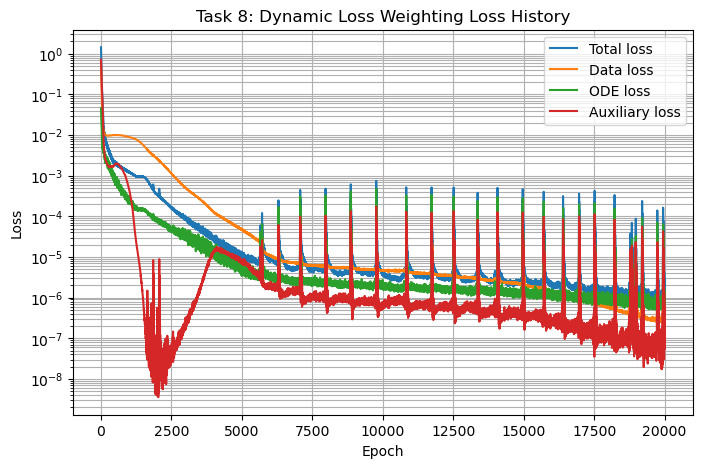

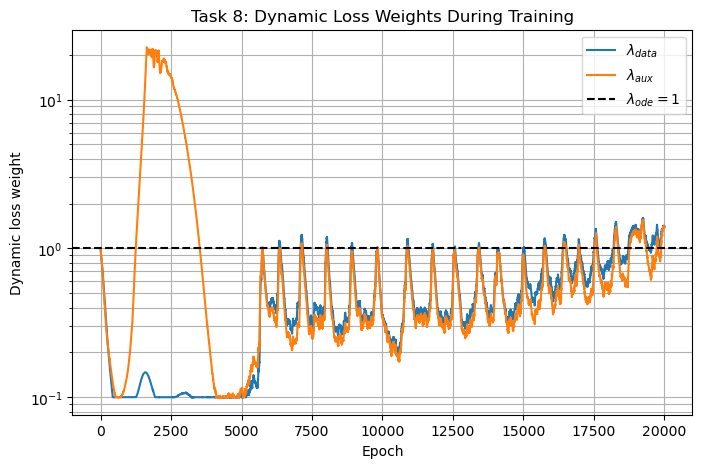

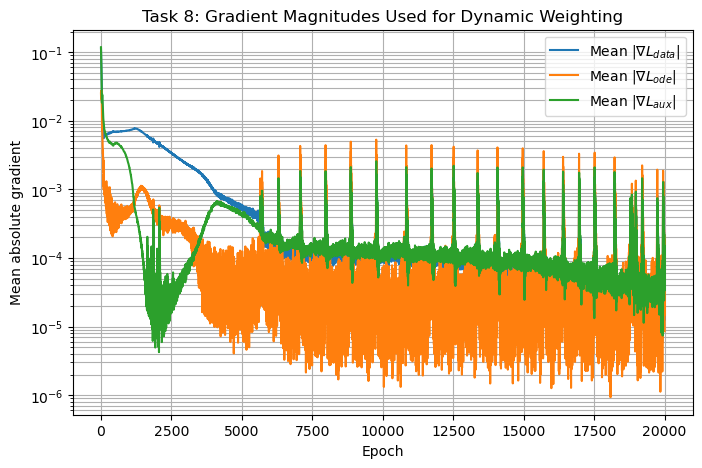

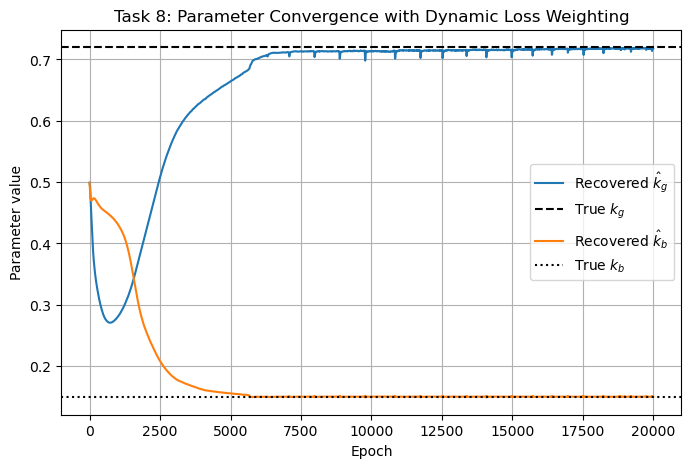

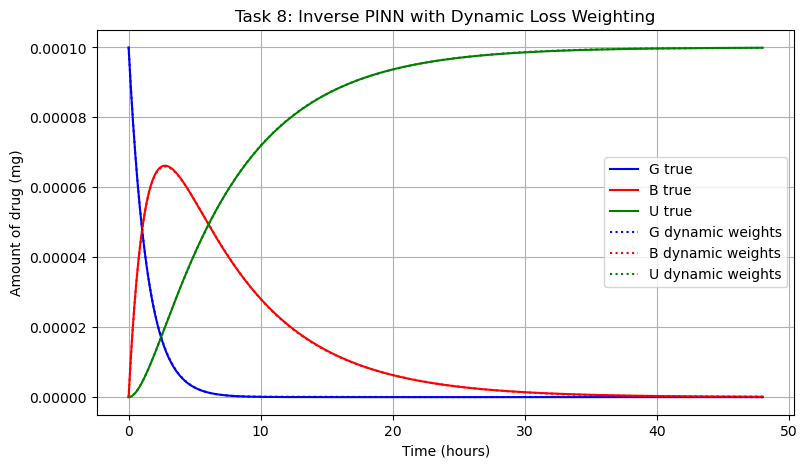

In [104]:
plt.figure(figsize=(8, 5))

plt.semilogy(dynamic_history["total"], label="Total loss")
plt.semilogy(dynamic_history["data"], label="Data loss")
plt.semilogy(dynamic_history["ode"], label="ODE loss")
plt.semilogy(dynamic_history["aux"], label="Auxiliary loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 8: Dynamic Loss Weighting Loss History")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8, 5))

plt.semilogy(dynamic_history["lambda_data"], label=r"$\lambda_{data}$")
plt.semilogy(dynamic_history["lambda_aux"], label=r"$\lambda_{aux}$")
plt.axhline(1.0, linestyle="--", color="black", label=r"$\lambda_{ode}=1$")

plt.xlabel("Epoch")
plt.ylabel("Dynamic loss weight")
plt.title("Task 8: Dynamic Loss Weights During Training")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8, 5))

plt.semilogy(dynamic_history["grad_data"], label=r"Mean $|\nabla L_{data}|$")
plt.semilogy(dynamic_history["grad_ode"], label=r"Mean $|\nabla L_{ode}|$")
plt.semilogy(dynamic_history["grad_aux"], label=r"Mean $|\nabla L_{aux}|$")

plt.xlabel("Epoch")
plt.ylabel("Mean absolute gradient")
plt.title("Task 8: Gradient Magnitudes Used for Dynamic Weighting")
plt.legend()
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(dynamic_history["kg"], label=r"Recovered $\hat{k}_g$")
plt.axhline(kg, linestyle="--", color="black", label=r"True $k_g$")

plt.plot(dynamic_history["kb"], label=r"Recovered $\hat{k}_b$")
plt.axhline(kb, linestyle=":", color="black", label=r"True $k_b$")

plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("Task 8: Parameter Convergence with Dynamic Loss Weighting")
plt.legend()
plt.grid(True)
plt.show()

y_pred_dynamic = dynamic_eval["y_pred_physical"]
t_plot = t_true_np.reshape(-1)

plt.figure(figsize=(9, 5))

plt.plot(t_plot, y_true_np[:, 0], "b-", label="G true")
plt.plot(t_plot, y_true_np[:, 1], "r-", label="B true")
plt.plot(t_plot, y_true_np[:, 2], "g-", label="U true")

plt.plot(t_plot, y_pred_dynamic[:, 0], "b:", label="G dynamic weights")
plt.plot(t_plot, y_pred_dynamic[:, 1], "r:", label="B dynamic weights")
plt.plot(t_plot, y_pred_dynamic[:, 2], "g:", label="U dynamic weights")

plt.xlabel("Time (hours)")
plt.ylabel("Amount of drug (mg)")
plt.title("Task 8: Inverse PINN with Dynamic Loss Weighting")
plt.legend()
plt.grid(True)
plt.show()

We get values of:
    - k_g error: 2.120e-03, k_b error: 4.114e-05, Normalized MSE: 4.732e-07, Relative L2 error: 1.306e-03.

Compared to the run without dynamic weights and the same hyperparameters:
    - k_g error: 3.937e-03, k_b error: 1.910e-04, Normalized MSE: 3.659e-06, Relative L2 error: 4.636e-03.

Adaptive loss weighing substantially improved the results of the inverse PINN compared to fixed loss weights under the same hyperparameters, with the k_g error improving by about 2x and the k_b error improving by about 4.5x. The normalized MSE and relative L2 error also improved significantly. This shows that adaptive loss weighting can help mitigate some of the optimization challenges in training PINNs for inverse problems by helping to balance the different loss terms and prevent any one term from dominating the optimization process. However, the training curves show more instability, with spikes caused by fluctuations in the dynamically updated weights. This indicates a tradeoff: adaptive loss weighting can mitigate optimization imbalance and improve inverse PINN accuracy, but it can also make training less stable. Therefore, the method helps address optimization-related poor conditioning, but it does not fully remove the underlying ill-posedness of the inverse problem. It should also be noted that adequate hyperparameter tuning is likely important to get the best results with adaptive loss weighting, and it is possible that further tuning could lead to even better results. Overall, adaptive loss weighing improves results but at a cost of training stability.

# References

[1] A. Yazdani et al., Systems biology informed deep learning for inferring parameters and hidden dynamics, PLoS Computational Biology, 16(11):e1007575, 2020. https://doi.org/10.1371/journal.pcbi.1007575